In [1]:
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import date, datetime, timedelta
from itertools import product
from copy import deepcopy
from gen_variable_standard_static import find_aggregate_variable_names_gen_mod, \
find_all_variable_names_gen_mod, check_variable_data_exists, sources_checker, \
check_variable_data_exists_single_system
from tqdm import tqdm

In [2]:
systems_cleaned = pd.read_csv('../../../data/core/systems_cleaned.csv')
systems_cleaned.columns

Index(['system_id', 'system_public_name', 'site_location',
       'timezone_or_utc_offset', 'latitude', 'longitude', 'elevation_m',
       'dc_capacity_kW', 'kg_climate', 'pvcz_composite', 'pvcz_t_rack',
       'pvcz_t_roof', 'pvcz_humidity', 'pvcz_wind', 'tracking', 'type',
       'azimuth', 'tilt', 'first_timestamp', 'last_timestamp', 'years',
       'number_records', 'dataset_size_mb', 'available_sensor_channels',
       'qa_status', 'qa_issue', 'first_year', 'is_prize_data',
       'is_lake_parquet_data', 'is_lake_csv_data', 'has_irradiance_data',
       'has_ambient_temperature_data', 'has_temperature_data',
       'has_power_data', 'has_current_data', 'has_voltage_data', 'has_ac_data',
       'has_dc_data', 'module_type', 'simplified_type', 'system_source',
       'sample_year', 'num_days_actual_records'],
      dtype='str')

In [3]:
systems_cleaned[['is_lake_parquet_data', 'has_power_data']].value_counts()

is_lake_parquet_data  has_power_data
False                 True              1701
True                  True               158
Name: count, dtype: int64

In [4]:
metrics_dir = Path("../../../data/raw/parquet-metrics/")
metrics_pq = pq.ParquetDataset(metrics_dir)
metrics_df = metrics_pq.read().to_pandas()
metrics_id_set = set(metrics_df.system_id)

# Early Ideas

In [5]:
system_id = 1416
relevant_rows_systems = systems_cleaned[systems_cleaned['system_id'] == system_id]
for j in relevant_rows_systems.index[0:1]:
    max_dc_capacity = relevant_rows_systems.loc[j, 'dc_capacity_kW']
    system_type = relevant_rows_systems.loc[j, 'simplified_type']
relevant_rows_metrics = metrics_df[metrics_df['system_id'] == system_id]

In [6]:
relevant_rows_systems

,system_id,system_public_name,site_location,timezone_or_utc_offset,latitude,longitude,elevation_m,dc_capacity_kW,kg_climate,pvcz_composite,...,has_power_data,has_current_data,has_voltage_data,has_ac_data,has_dc_data,module_type,simplified_type,system_source,sample_year,num_days_actual_records
143,1416,[1416] GSA Sanford Federal Building,"Raleigh, NC",7,35.7793,78.63411,110.0,564.5,ET,11,...,True,True,True,True,True,Unknown,unknown,PVDAQ General,2016,211


In [7]:
relevant_rows_metrics

,system_id,metric_id,sensor_name,common_name,raw_units,units,calc_scale,calc_offset,calc_details,aggregation_type,source_type,source_id,comments,standard_name
1107,1416,4742,dc_power,DC power,W,W,1.0,0.0,,avg,NaN,NaN,,dc_power__4742
1108,1416,4762,ac_current_phA,AC current,A,A,1.0,0.0,,avg,NaN,NaN,,ac_current_pha__4762
1109,1416,4763,ac_current_phB,AC current,A,A,1.0,0.0,,avg,NaN,NaN,,ac_current_phb__4763
1110,1416,4764,ac_current_phC,AC current,A,A,1.0,0.0,,avg,NaN,NaN,,ac_current_phc__4764
1111,1416,4749,ac_current,AC current,A,A,1.0,0.0,,avg,NaN,NaN,,ac_current__4749
1112,1416,4746,power_factor,AC other,-,-,1.0,0.0,,avg,NaN,NaN,,power_factor__4746
1113,1416,4753,power_factor_phA,AC other,-,-,1.0,0.0,,avg,NaN,NaN,,power_factor_pha__4753
1114,1416,4754,power_factor_phB,AC other,-,-,1.0,0.0,,avg,NaN,NaN,,power_factor_phb__4754
1115,1416,4755,power_factor_phC,AC other,-,-,1.0,0.0,,avg,NaN,NaN,,power_factor_phc__4755
1116,1416,4745,apparent_power_kVA,AC other,kVA,VA,1000.0,0.0,,avg,NaN,NaN,,apparent_power_kva__4745


In [8]:
no_max_inds = systems_cleaned['dc_capacity_kW'].isna()
bad_max_ind_systems = systems_cleaned.loc[no_max_inds, 'system_id']

In [9]:
len(bad_max_ind_systems)

65

In [10]:
no_verifier_systems = systems_cleaned[
    (systems_cleaned['dc_capacity_kW'].isna())
    & ((~systems_cleaned['has_current_data']) | (~systems_cleaned['has_voltage_data']))
]

In [11]:
no_verifier_systems.shape[0]

30

In [12]:
no_verifier_systems.head()

,system_id,system_public_name,site_location,timezone_or_utc_offset,latitude,longitude,elevation_m,dc_capacity_kW,kg_climate,pvcz_composite,...,has_power_data,has_current_data,has_voltage_data,has_ac_data,has_dc_data,module_type,simplified_type,system_source,sample_year,num_days_actual_records
30,1228,Mercury Solar Systems - Module Temperatures,"Port Chester, NY",America/New_York,40.9950,-73.6680,75.0,NaN,Cfa,33,...,True,False,False,True,False,Unknown,unknown,PVDAQ General,2012,978
71,1294,St. Petersburg Parks CDP - Coquina Key Park RB,"St Petersburg, FL",America/New_York,27.7374,-82.6311,5.0,NaN,Cfa,45,...,True,False,False,True,False,Unknown,unknown,PVDAQ General,2014,799
72,1295,St. Petersburg Parks CDP - Crisp Park RB,"St Petersburg, FL",America/New_York,27.8050,-82.6270,5.0,NaN,Cfa,45,...,True,False,False,True,False,Unknown,unknown,PVDAQ General,2014,686
73,1296,St. Petersburg Parks CDP - Dell Holmes Park RB,"St Petersburg, FL",America/New_York,27.7427,-82.6630,5.0,NaN,Cfa,45,...,True,False,False,True,False,Unknown,unknown,PVDAQ General,2014,514
74,1297,[1297] St. Petersburg Parks CDP - Demens Landi...,"St Petersburg, FL",America/New_York,27.7701,-82.6290,5.0,NaN,Cfa,45,...,True,False,False,True,False,Unknown,unknown,PVDAQ General,2014,218


In [13]:
len(set(bad_max_ind_systems).intersection(metrics_id_set))

39

## First search for metrics with fragments in the name

In [14]:
def metrics_search_for_fragment_df(df: pd.DataFrame, fragment: str):
    fragment = fragment.lower()
    return df[
        (df.loc[:, 'sensor_name'].str.contains(fragment, case=False))
        | (df.loc[:, 'common_name'].str.contains(fragment, case=False))
    ]

In [15]:
def metrics_search_for_two_fragments_df(df: pd.DataFrame, fragment_1: str,
                                        fragment_2: str, and_or: str):
    fragment_1 = fragment_1.lower()
    fragment_2 = fragment_2.lower()
    if and_or == 'and':
        return df[
            ((df.loc[:, 'sensor_name'].str.contains(fragment_1, case=False))
             | (df.loc[:, 'common_name'].str.contains(fragment_1, case=False)))
            & ((df.loc[:, 'sensor_name'].str.contains(fragment_2, case=False))
             | (df.loc[:, 'common_name'].str.contains(fragment_2, case=False)))
        ]
    elif and_or == 'or':
        return df[
            ((df.loc[:, 'sensor_name'].str.contains(fragment_1, case=False))
             | (df.loc[:, 'common_name'].str.contains(fragment_1, case=False)))
            | ((df.loc[:, 'sensor_name'].str.contains(fragment_2, case=False))
             | (df.loc[:, 'common_name'].str.contains(fragment_2, case=False)))
        ]

In [16]:
any_pow_systems = metrics_search_for_fragment_df(metrics_df, 'pow')
pow_ids = set(any_pow_systems.system_id)

In [17]:
len(pow_ids)

110

In [18]:
len(pow_ids.intersection(set(systems_cleaned.system_id)))

107

In [19]:
system_id_set = set(systems_cleaned.system_id)

In [20]:
pow_ids.difference(system_id_set)

{1251, 1327, 1341}

In [21]:
all_parquet_pow_data = systems_cleaned[
    systems_cleaned['has_power_data']
    & systems_cleaned['is_lake_parquet_data']
]

In [22]:
all_parquet_pow_ids = set(all_parquet_pow_data.system_id)

In [23]:
all_parquet_pow_ids.difference(pow_ids)

{1216,
 1218,
 1220,
 1222,
 1224,
 1226,
 1228,
 1294,
 1295,
 1296,
 1297,
 1298,
 1299,
 1301,
 1302,
 1303,
 1304,
 1309,
 1311,
 1334,
 1335,
 1336,
 1337,
 1338,
 1339,
 1340,
 1342,
 1343,
 1344,
 1345,
 1346,
 1347,
 1348,
 1349,
 1350,
 1351,
 1352,
 1353,
 1354,
 1355,
 1356,
 1357,
 1358,
 1359,
 1360,
 1361,
 1362,
 1363,
 1364}

In [24]:
# good, so the metrics_df parquet-power list contains the systems_cleaned metric_id list

In [25]:
pow_ids.difference(all_parquet_pow_ids)

{1251, 1327, 1341}

In [26]:
# but 109 systems with both flags set to true?

In [27]:
non_pow_systems = metrics_df.drop(index=any_pow_systems.index)
set(non_pow_systems.system_id)

{2,
 3,
 4,
 10,
 33,
 34,
 35,
 36,
 50,
 51,
 1199,
 1200,
 1201,
 1202,
 1203,
 1204,
 1207,
 1208,
 1214,
 1216,
 1217,
 1218,
 1219,
 1220,
 1221,
 1222,
 1223,
 1224,
 1225,
 1226,
 1228,
 1229,
 1230,
 1231,
 1239,
 1244,
 1245,
 1246,
 1248,
 1249,
 1250,
 1251,
 1252,
 1253,
 1254,
 1255,
 1256,
 1257,
 1258,
 1259,
 1260,
 1261,
 1262,
 1263,
 1264,
 1265,
 1266,
 1267,
 1268,
 1269,
 1270,
 1271,
 1272,
 1273,
 1274,
 1275,
 1276,
 1277,
 1278,
 1283,
 1284,
 1289,
 1294,
 1295,
 1296,
 1297,
 1298,
 1299,
 1300,
 1301,
 1302,
 1303,
 1304,
 1305,
 1306,
 1307,
 1308,
 1309,
 1310,
 1311,
 1312,
 1314,
 1315,
 1316,
 1317,
 1318,
 1319,
 1320,
 1321,
 1322,
 1323,
 1324,
 1325,
 1326,
 1327,
 1328,
 1329,
 1330,
 1331,
 1332,
 1334,
 1335,
 1336,
 1337,
 1338,
 1339,
 1340,
 1341,
 1342,
 1343,
 1344,
 1345,
 1346,
 1347,
 1348,
 1349,
 1350,
 1351,
 1352,
 1353,
 1354,
 1355,
 1356,
 1357,
 1358,
 1359,
 1360,
 1361,
 1362,
 1363,
 1364,
 1367,
 1368,
 1369,
 1403,
 1416,
 

In [28]:
# sample use -- search for ac and power
system_id = 1341
relevant_rows_metrics = metrics_df[metrics_df['system_id'] == system_id]
metrics_search_for_two_fragments_df(relevant_rows_metrics, 'pow', 'ac', 'and')

,system_id,metric_id,sensor_name,common_name,raw_units,units,calc_scale,calc_offset,calc_details,aggregation_type,source_type,source_id,comments,standard_name
905,1341,3497,ac_power_kW,AC power,kW,W,1000.0,0.0,,avg,NaN,NaN,,ac_power_kw__3497


Justify the inclusion of 'W_avg', 'RTW' in ac sensor names!

In [29]:
# show nothing but AC power
assert(set(metrics_df[metrics_df['sensor_name'] == 'W_avg'].common_name) == {'AC power'})
assert(set(metrics_df[metrics_df['sensor_name'] == 'RTW'].common_name) == {'AC power'})

# Towards getting All AC_Power system names

In [30]:
def widened_search_for_fragment_df(df: pd.DataFrame, fragment: str):
    fragment = fragment.lower()
    return df[
        (df.loc[:, 'sensor_name'].str.contains(fragment, case=False))
        | (df.loc[:, 'common_name'].str.contains(fragment, case=False))
        | (df.loc[:, 'calc_details'].str.contains(fragment, case=False))
        | (df.loc[:, 'source_type'].str.contains(fragment, case=False))
    ]

In [31]:
def widened_search_for_two_fragments_df(df: pd.DataFrame, fragment_1: str,
                                        fragment_2: str, and_or: str):
    fragment_1 = fragment_1.lower()
    fragment_2 = fragment_2.lower()
    if and_or == 'and':
        return df[
            ((df.loc[:, 'sensor_name'].str.contains(fragment_1, case=False))
             | (df.loc[:, 'common_name'].str.contains(fragment_1, case=False))
             | (df.loc[:, 'calc_details'].str.contains(fragment_1, case=False))
             | (df.loc[:, 'source_type'].str.contains(fragment_1, case=False)))
            & ((df.loc[:, 'sensor_name'].str.contains(fragment_2, case=False))
             | (df.loc[:, 'common_name'].str.contains(fragment_2, case=False))
             | (df.loc[:, 'calc_details'].str.contains(fragment_2, case=False))
             | (df.loc[:, 'source_type'].str.contains(fragment_2, case=False)))
        ]
    elif and_or == 'or':
        return df[
            ((df.loc[:, 'sensor_name'].str.contains(fragment_1, case=False))
             | (df.loc[:, 'common_name'].str.contains(fragment_1, case=False))
             | (df.loc[:, 'calc_details'].str.contains(fragment_1, case=False))
             | (df.loc[:, 'source_type'].str.contains(fragment_1, case=False)))
            | ((df.loc[:, 'sensor_name'].str.contains(fragment_2, case=False))
             | (df.loc[:, 'common_name'].str.contains(fragment_2, case=False))
             | (df.loc[:, 'calc_details'].str.contains(fragment_2, case=False))
             | (df.loc[:, 'source_type'].str.contains(fragment_2, case=False)))
        ]

In [32]:
power_data = metrics_search_for_fragment_df(metrics_df, 'pow')

In [33]:
widened_search_for_two_fragments_df(power_data, 'ac', 'met', 'and')

,system_id,metric_id,sensor_name,common_name,raw_units,units,calc_scale,calc_offset,calc_details,aggregation_type,source_type,source_id,comments,standard_name
51,1200,2751,ac_power,AC power,W,W,1.0,0.0,ac_power_metered_kW,avg,NaN,NaN,,ac_power__2751
71,1200,4197,ac_power_metered_kW,AC power,kW,W,1000.0,0.0,,avg,NaN,NaN,,ac_power_metered_kw__4197
124,1202,2802,ac_power_metered_kW,AC power,kW,W,1000.0,0.0,,avg,NaN,NaN,,ac_power_metered_kw__2802
143,1203,2889,ac_power,AC power,W,W,1.0,0.0,ac_meter_1_power_kW+ac_meter_2_power_kW,avg,NaN,NaN,,ac_power__2889
152,1203,2909,ac_meter_1_power_kW,AC power,kW,W,1000.0,0.0,,avg,NaN,NaN,,ac_meter_1_power_kw__2909
153,1203,2910,ac_meter_2_power_kW,AC power,kW,W,1000.0,0.0,,avg,NaN,NaN,,ac_meter_2_power_kw__2910
227,1208,1133,ac_power_metered_1_2,AC power,W,W,1.0,0.0,ac_meter_1_power_kW+ac_meter_2_power_kW,avg,NaN,NaN,,ac_power_metered_1_2__1133
230,1208,1016,ac_power_metered_kW,AC power,kW,W,1000.0,0.0,,avg,NaN,NaN,,ac_power_metered_kw__1016
231,1208,1017,ac_meter_1_power_kW,AC power,kW,W,1000.0,0.0,,avg,NaN,NaN,,ac_meter_1_power_kw__1017
232,1208,1018,ac_meter_2_power_kW,AC power,kW,W,1000.0,0.0,,avg,NaN,NaN,,ac_meter_2_power_kw__1018


Revised step one with inverter/meter/unknown data (and metadata improvements)

In [34]:
# Feel free to adjust these naming conventions for your variable.

def ac_pow_metadata_name(source_type: str):
    '''Give the name to put in the metadata table.'''
    if source_type is not None:
        return f'has_ac_power_{source_type}_aggregate'
    else:
        return f'has_ac_power_aggregate'


In [35]:
from gen_variable_standard_static import find_aggregate_variable_names_gen_mod, \
find_all_variable_names_gen_mod

In [36]:
def find_aggregate_ac_power_names(
    systems_cleaned: pd.DataFrame,
    metrics_df: pd.DataFrame,
    print_messages: bool,
    known_sources = ('inverter', 'meter'),
    known_sources_short = ('inv', 'met')
):
    var_name = 'ac_power'
    filtered_pow_metrics = metrics_search_for_two_fragments_df(
        metrics_df, 'ac', 'pow', 'and'
    )

    #after a manual search, these are the aggregate power names!
    ac_agg_sensor_names = ('ac_power', 'ac_power_hW', 'ac_power_kW', 'ac_power_1_6',
                           'InvPAC_kW_Avg', 'ac_power_calc', 'W_avg',
                           'ac_power_metered_kW', 'RTW',
                           'inv_total_ac_power', 'metered_ac_power',
                           'real_power_kW', 'ac_power_KwAC',
                           'ac_power_metered_1_2',
                           'ac_inverter_power',
                           'PwrMtrP_kW_Avg')

    return find_aggregate_variable_names_gen_mod(
        systems_cleaned=systems_cleaned,
        filtered_metrics_df=filtered_pow_metrics,
        var_name=var_name,
        agg_var_sensor_names=ac_agg_sensor_names,
        print_messages=print_messages,
        sources_matter=True,
        known_sources=known_sources,
        known_sources_short=known_sources_short
    )

In [37]:
all_agg_ac_pow, all_agg_ac_pow_meta = find_aggregate_ac_power_names(
    systems_cleaned=systems_cleaned,
    metrics_df=metrics_df,
    print_messages=True,
)

System 1200 has multiple ac_power aggregators from the meter source:
{'metric_id': np.int32(2751), 'sensor_name': 'ac_power', 'common_name': 'AC power', 'units': 'W', 'calc_details': 'ac_power_metered_kW', 'whole_or_part': 'whole', 'source_type': 'meter'}
{'metric_id': np.int32(4197), 'sensor_name': 'ac_power_metered_kW', 'common_name': 'AC power', 'units': 'W', 'calc_details': '', 'whole_or_part': 'whole', 'source_type': 'meter'}
System 1208 has multiple ac_power aggregators from the meter source:
{'metric_id': np.int32(1016), 'sensor_name': 'ac_power_metered_kW', 'common_name': 'AC power', 'units': 'W', 'calc_details': '', 'whole_or_part': 'whole', 'source_type': 'meter'}
{'metric_id': np.int32(1133), 'sensor_name': 'ac_power_metered_1_2', 'common_name': 'AC power', 'units': 'W', 'calc_details': 'ac_meter_1_power_kW+ac_meter_2_power_kW', 'whole_or_part': 'whole', 'source_type': 'meter'}
System 1283 has multiple ac_power aggregators from the meter source:
{'metric_id': np.int32(1137),

From data below, we make our conclusions on which meter sources to use:

**System 1200**: ac_power_metered_kW has less missingness, but whenever both exist, they agree exactly up to units
Later edit -- until ac_power disappears, at which point ac_power_metered_kW converts to W.  Still less missingness!

**System 1208  EDIT**: After appropriate re-scaling around the switch-time (2018, Aug. 4), `ac_power_metered_kW` keeps the same scale but `ac_power_metered_1_2` is doubled!  Keep `ac_power_metered_kW`

**System 1283**: Just weird!  dc power and ac inverter sum ~ 250 kW max; ac_power and ac_metered_inverter_kW are ~ 500 kW, but each pair has 1 W and 1 kW unit in practice!  (And switch at the switching time).
Probably just one of ac_power and ac_power_metered_kW, since at least they are close to each other.
Moreover, ac_power_metered_kW has less missingness without outlandish outliers.

In [38]:
all_agg_ac_pow_meta

,has_ac_power_aggregate,has_ac_power_inverter_aggregate,has_ac_power_meter_aggregate,has_ac_power_unknown_aggregate
4,True,False,False,True
10,True,False,False,True
33,True,False,False,True
34,True,False,False,True
35,True,False,False,True
...,...,...,...,...
1432,True,False,False,True
1433,True,False,False,True
4901,True,True,True,False
4902,True,True,True,False


In [39]:
all_agg_ac_pow[1202]

[{'metric_id': np.int32(2840),
  'sensor_name': 'ac_power',
  'common_name': 'AC power',
  'units': 'W',
  'calc_details': 'inv1_ac_power+inv2_ac_power+inv3_ac_power+inv4_ac_power+inv5_ac_power+inv6_ac_power',
  'whole_or_part': 'whole',
  'source_type': 'inverter'},
 {'metric_id': np.int32(2802),
  'sensor_name': 'ac_power_metered_kW',
  'common_name': 'AC power',
  'units': 'W',
  'calc_details': '',
  'whole_or_part': 'whole',
  'source_type': 'meter'}]

## Clarify units and power-factors before continuing

In [40]:
power_data = metrics_search_for_fragment_df(metrics_df, 'pow')
power_data[(power_data['common_name'].str.contains('ac', case=False))
           & ~(power_data['units'].isin(['W', 'kW']))]

,system_id,metric_id,sensor_name,common_name,raw_units,units,calc_scale,calc_offset,calc_details,aggregation_type,source_type,source_id,comments,standard_name
88,1200,4198,power_factor,AC other,-,-,1.000,0.0,,NaN,NaN,NaN,,power_factor__4198
94,1201,2799,power_factor,AC other,-,-,1.000,0.0,,avg,NaN,NaN,,power_factor__2799
141,1202,2805,power_factor,AC other,-,-,1.000,0.0,,NaN,NaN,NaN,,power_factor__2805
154,1203,2901,inv1_power_factor,AC other,-,-,1.000,0.0,,avg,NaN,NaN,,inv1_power_factor__2901
155,1203,2908,inv2_power_factor,AC other,-,-,1.000,0.0,,avg,NaN,NaN,,inv2_power_factor__2908
449,1276,3038,power_factor,AC other,-,-,1.000,0.0,,avg,NaN,NaN,,power_factor__3038
464,1277,3053,power_factor,AC other,-,-,1.000,0.0,,avg,NaN,NaN,,power_factor__3053
484,1278,3068,inv1_power_factor,AC other,-,-,1.000,0.0,,avg,NaN,NaN,,inv1_power_factor__3068
485,1278,3077,inv2_power_factor,AC other,-,-,1.000,0.0,,avg,NaN,NaN,,inv2_power_factor__3077
526,1284,957,power_factor,AC other,-,-,1.000,0.0,,avg,NaN,NaN,,power_factor__957


Thus, all power-terms not in W or kW are energy terms (kWh et c.), power-factors, and other components of complex power (the kVA and kVAR terms)  Not relevant for this part!

## Second Run -- Grab all AC power, non-power-factor terms.  

### Helper Functions

In [41]:
def ac_pow_metadata_part_name(source_type: str):
    '''Give the name to put in the metadata table.'''
    if source_type is not None:
        return f'has_ac_power_{source_type}_subsystems'
    else:
        return f'has_ac_power_subsystems'

def common_prefix_and_suffix(names_collection, first_name):
    '''Find the common prefix and suffix of a collection of the strings,
    with the first name in the collection set aside for ease of coding.'''
    common_prefix = ''
    j = 0
    good_prefix = True
    max_len = len(first_name)
    while good_prefix:
        if all(
            [name.startswith(common_prefix) for name in names_collection]
        ):
            j += 1
            common_prefix = first_name[0:j]
            if j >= max_len + 1:
                print('Common prefix is whole thing!')
                good_prefix = False
                common_prefix = first_name
        else: # bad prefix, back it up one
            good_prefix = False
            common_prefix = common_prefix[0:-1]
    common_suffix = ''
    j = 0 
    good_suffix = True
    while good_suffix:
        if all(
            [name.endswith(common_suffix) for name in names_collection]
        ):
            j += 1
            common_suffix = first_name[-j:]
            if j >= max_len + 1:
                print('Common suffix is whole thing!')
                good_suffix = False
                common_suffix = first_name
        else: # take the last amendment off
            good_suffix = False
            common_suffix = common_suffix[1:]
    return (common_prefix, common_suffix)

In [ ]:
def find_all_ac_power_names(
    systems_cleaned: pd.DataFrame,
    metrics_df: pd.DataFrame,
    print_messages: bool = False,
    known_sources=('inverter', 'meter'),
    known_sources_short=('inv', 'met'),
    drop_competing_meter_data: bool = True):
    '''Add subsystem names to aggregation names for each ac-power system.
    
    Parameters
    -----------
    systems_cleaned: pandas.DataFrame
        The cleaned-system data
    metrics_df: pd.DataFrame
        The data-frame of all relevangt metrics
    print_messages: bool
        Whether or not to reprint previous-phase messages here.
        Should probably be False.
    known_sources: iterable of strings
        An iterable of known sources.
    known_sources_short: iterable of strings
        An iterable of shorthands.  Must be the same length as known_sources.
    drop_competing_meter_data:
        Drop the known overlpas in Systems 1200, 1208, 1283
        True for run-through
        False for testing
    
    Returns
    -----------
    var_total_dict: dict[list[dict]]
        A dictionary, indexed by relevant system_id's.
        The value of var_total_dict[system_id] is a list of dictionaries,
        one for each variable-related metric for the systems_id.
            "metric_id" -- the metric_id number
            "sensor_name" -- the sensor_name term
            "common_name" -- the common-name term
            "units" -- the units for each term
            "whole_or_part" -- determining whether each term is aggregate or a sub-part
        If sources_matter = True, then add
            "source_type": the source type if known, or "unknown" if unknown
        If a sub-part, add in
            "index" -- the identifying string of the sub-part
    var_total_metadata_df: pandas.DataFrame
        If sources_matter = True, then a DataFrame indicating both
        which systems have aggregate variable data, 
        which systems have subpart variable data,
        and the breakdowns per subtype
        If sources_matter = False, a DataFrame indicating which systems have 
        aggregate and subpart variable data only.  
    '''
    var_name = 'ac_power'
    sources_matter=True
    #after a manual search, these are the aggregate power names!
    ac_agg_sensor_names = ('ac_power', 'ac_power_hW', 'ac_power_kW', 'ac_power_1_6',
                           'InvPAC_kW_Avg', 'ac_power_calc', 'W_avg',
                           'ac_power_metered_kW', 'RTW',
                           'inv_total_ac_power', 'metered_ac_power',
                           'real_power_kW', 'ac_power_KwAC',
                           'ac_power_metered_1_2',
                           'ac_inverter_power',
                           'PwrMtrP_kW_Avg')

    agg_power_metrics, agg_power_metadata = find_aggregate_ac_power_names(
        systems_cleaned=systems_cleaned,
        metrics_df = metrics_df,
        print_messages=print_messages,
        known_sources=known_sources,
        known_sources_short=known_sources_short
    )
    ac_power_metrics = metrics_search_for_two_fragments_df(
        metrics_df, 'ac', 'pow', 'and'
    )
    # to filter to non-power-factor terms, it happens to work
    # to filter each term to units 'W', 'kW'
    # (don't try this with dc_power without cleaning, though!)
    non_power_factor_metrics = ac_power_metrics[
        ac_power_metrics['units'].isin(['W', 'kW'])
    ]
    all_ac_pow_metrics, all_ac_pow_metadata = find_all_variable_names_gen_mod(
        var_aggs_dict=agg_power_metrics,
        var_aggs_metadata=agg_power_metadata,
        filtered_metrics_df=non_power_factor_metrics,
        var_name=var_name,
        agg_var_sensor_names=ac_agg_sensor_names,
        sources_matter=sources_matter,
        known_sources=known_sources,
        known_sources_short=known_sources_short
    )
    if drop_competing_meter_data:
        # make the override -- drop the duplicates aggregates from the previous step.
        # had to wait till now, because otherwise they would be added again.
        known_sources, known_sources_short = sources_checker(
            known_sources, known_sources_short
        )
        for system_id in all_ac_pow_metrics.keys():
            num_aggs_by_type = {
                source_type: 0 for source_type in known_sources
            }
            for metric_dict in all_ac_pow_metrics[system_id]:
                if metric_dict['whole_or_part'] == 'whole':
                    num_aggs_by_type[metric_dict['source_type']] += 1
            for source_type in known_sources:
                if num_aggs_by_type[source_type] > 1:
                    assert(system_id in [1200, 1208, 1283])
                    for (system_id, duplicate_to_remove) in (
                        (1200, 'ac_power'), (1208, 'ac_power_metered_1_2'),
                        (1283, 'ac_power')
                    ):
                        for e, metric_dict in enumerate(all_ac_pow_metrics[system_id]):
                            if metric_dict['sensor_name'] == duplicate_to_remove:
                                all_ac_pow_metrics[system_id].pop(e)
                                break
    
    return (all_ac_pow_metrics, all_ac_pow_metadata)

In [43]:
all_ac_power_names, all_ac_power_meta = find_all_ac_power_names(
    systems_cleaned=systems_cleaned,
    metrics_df=metrics_df,
    print_messages=False,
    drop_competing_meter_data=False  # change to test missingness
)

In [44]:
check_variable_data_exists_single_system(
    all_ac_power_names, 
    all_ac_power_meta,
    '../../../../data_ds_project/systems/parquet/',
    1422,
    'ac_power',
    True
)

([{'metric_id': np.int32(4830),
   'sensor_name': 'inv1_ac_power',
   'common_name': 'AC power',
   'units': 'W',
   'calc_details': '',
   'whole_or_part': 'part',
   'source_type': 'inverter',
   'index': '1'},
  {'metric_id': np.int32(4836),
   'sensor_name': 'inv2_ac_power',
   'common_name': 'AC power',
   'units': 'W',
   'calc_details': '',
   'whole_or_part': 'part',
   'source_type': 'inverter',
   'index': '2'}],
 has_ac_power_aggregate              False
 has_ac_power_inverter_aggregate     False
 has_ac_power_meter_aggregate        False
 has_ac_power_unknown_aggregate      False
 has_ac_power_subsystems              True
 has_ac_power_inverter_subsystems     True
 has_ac_power_meter_subsystems       False
 has_ac_power_unknown_subsystems     False
 Name: 1422, dtype: bool)

Run this next line only if you have 70 minutes of time!

In [65]:
for system_id in tqdm(all_ac_power_names.keys()):
    (my_ac_power_names_trimmed, my_ac_power_meta_trimmed) = check_variable_data_exists_single_system(
        all_ac_power_names,
        all_ac_power_meta,
        '../../../../data_ds_project/systems/parquet/',
        system_id,
        'ac_power',
        sources_matter=True,
    )
    if len(all_ac_power_names[system_id]) > len(my_ac_power_names_trimmed):
        print(system_id)

 94%|█████████▍| 96/102 [1:06:21<05:53, 58.99s/it] 

1422


 95%|█████████▌| 97/102 [1:07:52<05:43, 68.72s/it]

1423


 96%|█████████▌| 98/102 [1:08:15<03:40, 55.00s/it]

1429


100%|██████████| 102/102 [1:08:47<00:00, 40.47s/it]


Just in case it gets erased, 1422, 1423, 1429 are the only systems that actually require trimming in this way (for ac power).  We can save ourselves the time otherwise.

### Sanity Check -- no missing aggregate names

In [44]:
part_metric_names = []
for system_id in all_ac_power_names.keys():
    for metric_dict in all_ac_power_names[system_id]:
        if metric_dict['whole_or_part'] == 'part':
            part_metric_names.append(metric_dict['sensor_name'])
part_metric_names.sort()
for metric_name in part_metric_names:
    print(metric_name)

ac_meter_1_power_kW
ac_meter_1_power_kW
ac_meter_1_power_kW
ac_meter_2_power_kW
ac_meter_2_power_kW
ac_meter_2_power_kW
ac_power_1
ac_power_1
ac_power_1
ac_power_1
ac_power_1
ac_power_1
ac_power_1
ac_power_1
ac_power_1
ac_power_1_KwAC
ac_power_1_KwAC
ac_power_2
ac_power_2
ac_power_2
ac_power_2
ac_power_2
ac_power_2
ac_power_2
ac_power_2
ac_power_2
ac_power_2_KwAC
ac_power_2_KwAC
ac_power_3
ac_power_3
ac_power_3
ac_power_3
ac_power_3
ac_power_3
ac_power_3
ac_power_3_KwAC
ac_power_4
ac_power_4
ac_power_5
ac_power_5
ac_power_6
ac_power_6
inv1_ac_power
inv1_ac_power
inv1_ac_power
inv1_ac_power
inv1_ac_power
inv1_ac_power
inv1_ac_power
inv1_ac_power
inv1_ac_power
inv1_ac_power
inv1_ac_power_hW
inv1_ac_power_hW
inv1_ac_power_kW
inv1_ac_power_kW
inv1_ac_power_kW
inv2_ac_power
inv2_ac_power
inv2_ac_power
inv2_ac_power
inv2_ac_power
inv2_ac_power
inv2_ac_power
inv2_ac_power
inv2_ac_power
inv2_ac_power
inv2_ac_power
inv2_ac_power_hW
inv2_ac_power_hW
inv2_ac_power_kW
inv2_ac_power_kW
inv3_ac_powe

#### Another check -- is 'unknown' ever paired with other location types?

In [45]:
all_ac_power_meta[['has_ac_power_inverter_aggregate', 'has_ac_power_meter_aggregate', 'has_ac_power_unknown_aggregate']].value_counts()

has_ac_power_inverter_aggregate  has_ac_power_meter_aggregate  has_ac_power_unknown_aggregate
False                            False                         True                              85
True                             False                         False                              6
                                 True                          False                              6
False                            True                          False                              5
Name: count, dtype: int64

In [46]:
all_ac_power_meta[['has_ac_power_subsystems', 'has_ac_power_inverter_subsystems', 'has_ac_power_meter_subsystems', 'has_ac_power_unknown_subsystems']].value_counts()

has_ac_power_subsystems  has_ac_power_inverter_subsystems  has_ac_power_meter_subsystems  has_ac_power_unknown_subsystems
False                    False                             False                          False                              75
True                     False                             False                          True                               12
                         True                              False                          False                              11
                                                           True                           False                               4
Name: count, dtype: int64

Nope!  (Hence, for variable data as opposed to metadata, can leave the unknown off.)

Any parts without subparts?

In [47]:
all_ac_power_meta[['has_ac_power_aggregate', 'has_ac_power_subsystems']].value_counts()

has_ac_power_aggregate  has_ac_power_subsystems
True                    False                      75
                        True                       27
Name: count, dtype: int64

In [48]:
for source_type in ['inverter', 'meter', 'unknown']:
    print(all_ac_power_meta[[ac_pow_metadata_name(source_type), ac_pow_metadata_part_name(source_type)]].value_counts())

has_ac_power_inverter_aggregate  has_ac_power_inverter_subsystems
False                            False                               84
True                             True                                 9
False                            True                                 6
True                             False                                3
Name: count, dtype: int64
has_ac_power_meter_aggregate  has_ac_power_meter_subsystems
False                         False                            91
True                          False                             7
                              True                              4
Name: count, dtype: int64
has_ac_power_unknown_aggregate  has_ac_power_unknown_subsystems
True                            False                              73
False                           False                              17
True                            True                               12
Name: count, dtype: int64


Some inverter systems not summed!  For ac power, may *want* to sum them!

## Compilation of AC Power Data

In [45]:
def ac_power_total_name(source_type: str, has_subparts: bool, unit: str = 'W'):
    '''Make the standardized variable name.'''
    total_name = 'ac_power'
    if (source_type is not None) and (source_type != 'unknown'):
        total_name = total_name + '_' + source_type
    if has_subparts:
        total_name = total_name + '_total'
    total_name = total_name + '_' + unit
    return total_name


def ac_power_partial_name(source_type: str, ind: int, unit: str = 'W'):
    '''Make the standardized part-name.'''
    subpart_name = 'ac_power'
    if (source_type is not None) and (source_type != 'unknown'):
        subpart_name = subpart_name + '_' + source_type
    subpart_name = subpart_name + f'_{ind}_{unit}'
    return subpart_name

## Last step -- make the dataframe

### Still debugging the renaming parts of this function

In [46]:
all_data_systems = systems_cleaned[
    systems_cleaned['has_current_data']
    & systems_cleaned['has_irradiance_data']
    & systems_cleaned['has_power_data']
    & systems_cleaned['has_temperature_data']
    & systems_cleaned['has_voltage_data']
]
all_data_ids = set(all_data_systems.system_id)

parquet_systems = systems_cleaned.loc[
    systems_cleaned.loc[:, 'is_lake_parquet_data']
]  # is already boolean!
all_parquet_system_ids = list(parquet_systems.system_id.unique())
all_parquet_system_ids.sort()

all_rich_parquet_data_ids = set(all_data_systems.system_id.unique()).intersection(
    set(all_parquet_system_ids)
)
all_rich_parquet_data_ids = list(all_rich_parquet_data_ids)
all_rich_parquet_data_ids.sort()

In [47]:
def find_good_date(system_id: int,
                   systems_cleaned: pd.DataFrame,
                   error_out: bool = True):
    '''Find a good date to check for ac power production,
    based on satellite irradiance figures.'''
    relevant_rows_systems = systems_cleaned[systems_cleaned['system_id']==system_id]
    ind = relevant_rows_systems.index[0]
    target_year = int(relevant_rows_systems.loc[ind, 'sample_year'])
    if target_year < 1999:
        target_year = 1999
    my_irrad_address = '../../../../data_ds_project/systems/parquet_irrad_samples/'\
        + f'{system_id}_{target_year}_irradiance.csv'
    # skip header of two rows at the start
    try: 
        irrad_data_target_year = pd.read_csv(my_irrad_address, skiprows=2)
    except pd.errors.EmptyDataError as e:
        print(system_id)
        if error_out:
            raise e
        else:
            return None
    except BaseException as e:
        raise e
    
    irrad_data_nonzero = irrad_data_target_year[irrad_data_target_year['DHI'] >= 1]
    # find a good day
    irrad_75 = np.quantile(irrad_data_nonzero['DHI'].values, 0.75)
    irrad_good_hours = irrad_data_nonzero[irrad_data_nonzero['DHI'] >= irrad_75]
    irrad_good_hours_counts = irrad_good_hours.groupby(['Year', 'Month', 'Day'])['DHI'].count()
    max_count = irrad_good_hours_counts.max()
    # prefer spring/fall to summer/winter -- good irradiance without temperature extremes
    preference_months = [4, 9, 3, 10, 5, 8, 2, 11, 1, 12, 6, 7]
    for (month, day) in product(preference_months, range(1, 32)):
        try:
            this_day_figure = irrad_good_hours_counts[target_year][month][day]
            if this_day_figure == max_count:
                good_date = date(target_year, month, day)
                break
        except KeyError as e:
            continue
        except BaseException as e:
            raise e
    # load the data for that good day
    return good_date
    


In [48]:
find_good_date(4901, systems_cleaned, True)

datetime.date(2015, 6, 10)

In [82]:
# test
for system_id in all_parquet_system_ids:
    find_good_date(system_id=system_id, systems_cleaned=systems_cleaned, error_out=False)

1416


In [83]:
systems_cleaned[systems_cleaned['system_id'] == 1416]['num_days_actual_records']

143    211
Name: num_days_actual_records, dtype: int64

Something's up with the first year for System 1416, but irrelevant, as it doesn't have enough days of data to make it worthwhile, anyways!

In [48]:
def temp_agg_name(source_type):
    '''Provide the temporary manual-aggregate name just for reference later.'''
    return f'ac_power_{source_type}_artificial_sum'

In [49]:
def ac_power_gather_data(
    all_ac_pow_metrics,
    all_ac_pow_metadata: pd.DataFrame,
    system_id: int,
    error_on_no_data: bool,
    add_aggs: bool,
    known_sources = ('inverter', 'meter'),
    known_sources_short = ('inv', 'met'),
):
    '''Gather all ac power-data per-system,
    given a list of aggregate sensor names.
    
    Parameters
    ----------
    all_ac_pow_metrics
        first result of find_all_ac_power_names(*args)
    all_ac_pow_metadata
        second result of find_all_ac_power_names(*args)
    system_id: int
        Index of system in systems_cleaned and metric_df
    tall_or_wide: str
        If 'wide', return wide DataFrame
        if 'tall', convert back to a 3-column array.
    error_in_no_data: bool
        If True, return an error if the system_id has no ac-power data.
        If False, return None if the system-system_id has no ac-power data.
    add_aggs: bool
        If True, and there are parts without a corresponding aggregate,
            add the aggregate, according to agg_type.
        If False, do nothing.
    print_warnings: bool
        Print warnings about too few or too many aggregators.
    known_sources: iterable of strings
        Full names of the known source types.
    known_sources_short: iterable of strings
        fragments of the known source names suitable for searching

    Returns
    --------
    A pandas DataFrame object with the desired data.
    '''
    known_sources, known_sources_short = sources_checker(
        known_sources, known_sources_short
    )
    # specialize to current ID number
    try:
        my_ac_power_names = deepcopy(all_ac_pow_metrics[system_id])
        my_ac_power_metadata = all_ac_pow_metadata.loc[system_id, :]
    except KeyError:
        if error_on_no_data:
            raise ValueError(f'System {system_id} has no AC Power data!')
        else:
            return None
    except BaseException as e:
        raise e
    # for known problem-cases, clean the data of spurious variables
    if system_id in [1422, 1423, 1429]:
        (my_ac_power_names, my_ac_power_metadata) = check_variable_data_exists_single_system(
            var_total_dict=all_ac_pow_metrics,
            var_total_metadata_df=all_ac_pow_metadata,
            path_to_raw_data_dir='../../../../data_ds_project/systems/parquet/',
            system_id=system_id,
            var_name='ac_power',
            sources_matter=True,
            known_sources=known_sources,
            known_sources_short=known_sources_short
        )
    # grab some metadata, quickly
    metric_ids = []
    whole_metric_ids = []
    source_type_metric_ids = {
        source_type: [] for source_type in known_sources
    }
    # grab all metric ids, putting the 'whole' category first
    for metric_data_dict in my_ac_power_names:
        if metric_data_dict['whole_or_part'] == 'whole':
            metric_ids.insert(0, metric_data_dict['metric_id'])
            whole_metric_ids.append(metric_data_dict['metric_id'])
        elif metric_data_dict['whole_or_part'] == 'part':
            metric_ids.append(metric_data_dict['metric_id'])
        else:
            raise ValueError('The "whole_or_part" result of find_all_ac_power_names()\n'
                             f'is not correct for system {system_id}.')
        source_type_metric_ids[metric_data_dict['source_type']].append(
            metric_data_dict['metric_id']
        )
    # Load only these metrics from the system
    my_system_parquet_data_path = Path(f'../../../../data_ds_project/systems/parquet/{system_id}/')
    my_system_parquet_selection = pq.ParquetDataset(
        my_system_parquet_data_path, filters=[
            ('metric_id', 'in', metric_ids)
        ]
    )
    system_df = my_system_parquet_selection.read().to_pandas()
    # for reference, 4 columns (see
    # https://github.com/openEDI/documentation/blob/main/pvdaq.md#pvdaq_pvdata)
    # measured_on, utc_measured_on, metric_id, value)
    # standard cleaning
    # do we actually have all of the data
    if len(set(system_df['metric_id'])) != len(metric_ids):
        missing_ids = set(metric_ids).difference(set(system_df['metric_id']))
        print(f'Missing ids: {missing_ids}')
        raise ValueError('metrics not found!')


    system_df = system_df.drop_duplicates()
    # See if multiple values at a given time
    # if so, forced to replace value by mean value
    if any(system_df.duplicated(subset = ['measured_on', 'metric_id'])):
        system_df.loc[:, 'mean_value'] = system_df.groupby(
            ['measured_on', 'metric_id']
        )['value'].transform('mean')
        system_df = system_df.drop(columns='value')
        system_df = system_df.rename(columns={'mean_value':'value'})
        system_df.drop_duplicates()
    # if still duplicates, forced to drop utc_measured_on,
    # a frequent source of off-by-one-hour errors
    # (and points with the same 'measured_on' but different 'utc_measured_on'
    # have the same value, so it is likely that utc_measured_on is the problem)
    if any(system_df.duplicated(subset = ['measured_on', 'metric_id', 'value'])):
        system_df = system_df.drop(columns='utc_measured_on')
        system_df = system_df.drop_duplicates()
    # ready to widen the columns
    wide_df = system_df.pivot(
        index='measured_on',
        columns='metric_id',
        values='value'
    )
    # reset the metric_id name of the index of columns
    wide_df.columns.name = ''
    # reset the index
    wide_df = wide_df.reset_index()
    # Some systems have part-data and not aggregate data;  
    # amend this mistake.
    if add_aggs:
        for source_type in known_sources:
            if (my_ac_power_metadata[ac_pow_metadata_part_name(source_type)])\
              and (not my_ac_power_metadata[ac_pow_metadata_name(source_type)]):
                source_type_total_name = temp_agg_name(source_type=source_type)
                # as agg_type == 'sum' in gen_variable_standardizer
                wide_df[source_type_total_name] = wide_df.apply(
                    lambda row: np.sum(
                        [row[j] for j in source_type_metric_ids[source_type]]
                    ), axis=1
                )
                sensor_names_summed = []
                units_group = []
                for metric_dict in my_ac_power_names:
                    if metric_dict['metric_id'] in source_type_metric_ids[source_type]:
                        sensor_names_summed.append(metric_dict['sensor_name'])
                        units_group.append(metric_dict['units'])
                calc_type = sensor_names_summed[0]
                for j in range(1, len(sensor_names_summed)):
                    calc_type = f'{calc_type} + {sensor_names_summed[j]}'
                units_group = set(units_group)
                if len(units_group) == 1:
                    # grab the singleton as our unit
                    # see https://stackoverflow.com/questions/1619514/how-to-extract-the-member-from-single-member-set-in-python
                    # for more info on this
                    (my_unit, ) = units_group
                else:
                    raise RuntimeError('Multiple units in the subparts summed!  No good!')
                whole_metric_ids.append(source_type_total_name)
                source_type_metric_ids[source_type].append(
                    source_type_total_name
                )
                # adjoin new variables to our metadata lists as well
                my_ac_power_metadata[ac_pow_metadata_name(source_type)] = True
                my_ac_power_names.append(
                    {
                        'sensor_name': source_type_total_name,
                        'units': my_unit,
                        'calc_type': calc_type,
                        'common_name': 'AC power',
                        'metric_id': 'N/A',
                        'whole_or_part': 'whole',
                        'source_type': source_type
                    }
                )

    # preserve 'whole' columns
    whole_columns = ['measured_on',] + whole_metric_ids 
    wide_df = wide_df[whole_columns]
    renamer_dict = dict()
    for metric_data_dict in my_ac_power_names:
        renamer_dict[metric_data_dict['metric_id']] = metric_data_dict['sensor_name']
    wide_df = wide_df.rename(columns=renamer_dict)
    
    return(my_ac_power_names, my_ac_power_metadata, wide_df)
    

In [ ]:
(rev_names_1200, rev_meta_1200, agg_data_1200) = ac_power_gather_data(all_ac_pow_metrics=all_ac_power_names, all_ac_pow_metadata=all_ac_power_meta,
                     system_id=1200, error_on_no_data=True, add_aggs=True)

In [ ]:
rev_meta_1200

In [ ]:
agg_data_1200

In [ ]:
all_ac_power_names[1422]

In [67]:
(rev_names_1422, rev_meta_1422, agg_data_1422) = ac_power_gather_data(all_ac_pow_metrics=all_ac_power_names, all_ac_pow_metadata=all_ac_power_meta,
                     system_id=1422, error_on_no_data=True, add_aggs=True)

In [68]:
rev_names_1422

[{'metric_id': np.int32(4830),
  'sensor_name': 'inv1_ac_power',
  'common_name': 'AC power',
  'units': 'W',
  'calc_details': '',
  'whole_or_part': 'part',
  'source_type': 'inverter',
  'index': '1'},
 {'metric_id': np.int32(4836),
  'sensor_name': 'inv2_ac_power',
  'common_name': 'AC power',
  'units': 'W',
  'calc_details': '',
  'whole_or_part': 'part',
  'source_type': 'inverter',
  'index': '2'},
 {'sensor_name': 'ac_power_inverter_artificial_sum',
  'units': 'W',
  'calc_type': 'inv1_ac_power + inv2_ac_power',
  'common_name': 'AC power',
  'metric_id': 'N/A',
  'whole_or_part': 'whole',
  'source_type': 'inverter'}]

In [69]:
agg_data_1422.head()

,measured_on,ac_power_inverter_artificial_sum
0,2014-11-17 11:25:00,82.78778
1,2014-11-17 11:26:00,90.93769
2,2014-11-17 11:27:00,94.85898
3,2014-11-17 11:28:00,101.68348
4,2014-11-17 11:29:00,108.09315


In [108]:
(rev_names_4901, rev_meta_4901, agg_data_4901) = ac_power_gather_data(all_ac_pow_metrics=all_ac_power_names, all_ac_pow_metadata=all_ac_power_meta,
                     system_id=4901, error_on_no_data=True, add_aggs=True)

In [79]:
for system_id in all_rich_parquet_data_ids:
    ac_power_gather_data(all_ac_pow_metrics=all_ac_power_names, all_ac_pow_metadata=all_ac_power_meta,
                     system_id=system_id, error_on_no_data=False, add_aggs=True)

Before doing units-testing code, check for *consistent* units.

Next thing to do, though, is check whether or not the scale is consistent -- that our sample data is not bad (ignoring 1200 and 1416)

In [50]:
def unit_scale_consistency(
    system_id: int,
    systems_cleaned: pd.DataFrame
):
    (my_metrics, my_metadata, my_data) = ac_power_gather_data(
        all_ac_pow_metrics=all_ac_power_names, all_ac_pow_metadata=all_ac_power_meta,
        system_id=system_id, error_on_no_data=True, add_aggs=True
    )
    whole_metrics_names = []
    for metric_dict in my_metrics:
        if metric_dict['whole_or_part'] == 'whole':
            whole_metrics_names.append(metric_dict['sensor_name'])
    # get yearly averages
    my_data['year'] = my_data['measured_on'].dt.year
    yearly_maxes = my_data.groupby('year').max()
    yearly_maxes = yearly_maxes.drop(columns='measured_on')
    return yearly_maxes
    

In [52]:
all_parquet_pow_ids_list = list(all_parquet_pow_ids)
all_parquet_pow_ids_list.sort()
for system_id in all_parquet_pow_ids_list:
    try:
        my_ac_power_names = deepcopy(all_ac_power_names[system_id])
    except KeyError as e:
        continue
    except BaseException as e:
        raise e
    print(f'System {system_id}')
    year_avgs = unit_scale_consistency(system_id, systems_cleaned)
    print(year_avgs)
    print('')

System 4
       ac_power
year           
2007  1009.8260
2008  1042.1450
2009  1022.8320
2010  1803.3210
2011  1147.8350
2012  2101.9460
2013  1118.2390
2014  1802.0990
2015  1126.7100
2016  1158.8080
2017   869.4875
2018  1090.9230
2019  1184.9400
2020  1111.4250
2021  1153.8350
2022  1091.8980
2023  1091.2920

System 10
      ac_power
year          
2000    248.57
2006   1239.40
2007   1243.90
2008   1164.40
2009   1263.40
2010   1387.50
2011   1746.60
2012   1448.40
2013   1364.00
2014   1441.90
2015   1400.80
2016   1378.20
2017   1315.00
2018   1330.10
2019   1339.50
2020   1276.50
2021   1294.40
2022   1243.20
2023   1153.90

System 33
      ac_power
year          
2010  2536.844
2011  7809.000
2012  2880.922
2013  2690.862
2014  2895.443
2015  2662.946
2016  2770.334
2017  2759.048
2018  2763.805
2019  2888.549
2020  2727.037
2021  2710.544
2022  2708.802
2023  2634.244

System 34
      ac_power_hW
year             
2010       1337.0
2011       1339.0
2012       1337.0
2013     

Let's localize the affected systems to the month.

In [51]:
switch_unit_systems = [34, 35, 1200, 1201, 1202, 1208,
                       1239, 1276, 1277, 1283, 1332, 1420]

In [63]:
for system_id in switch_unit_systems:
    (my_metrics, my_metadata, my_data) = ac_power_gather_data(
        all_ac_pow_metrics=all_ac_power_names, all_ac_pow_metadata=all_ac_power_meta,
        system_id=system_id, error_on_no_data=True, add_aggs=True
    )
    whole_metrics_names = []
    for metric_dict in my_metrics:
        if metric_dict['whole_or_part'] == 'whole':
            whole_metrics_names.append(metric_dict['sensor_name'])
    # get 2018 monthly averages
    my_data['year'] = my_data['measured_on'].dt.year
    my_data['month'] = my_data['measured_on'].dt.month
    my_data_restrict = my_data[(my_data['year']==2018)]
    monthly_maxes = my_data_restrict.groupby(['year', 'month']).max()
    monthly_maxes = monthly_maxes.drop(columns=['measured_on'])
    print(f'System {system_id}')
    print(monthly_maxes)
    print('')

System 34
            ac_power_hW
year month             
2018 1           1062.0
     2           1227.0
     3           1337.0
     4           1310.0
     5           1239.0
     6           1162.0
     7           1144.0
     8         115100.0
     9         101700.0
     10        119300.0
     11         97700.0
     12        110900.0

System 35
            ac_power_hW
year month             
2018 1            814.0
     2            966.0
     3           1121.0
     4           1097.0
     5           1066.0
     6            936.0
     7            919.0
     8          91500.0
     9          85300.0
     10        106200.0
     11         70700.0
     12         82600.0

System 1200
            ac_power  ac_power_metered_kW  ac_power_inverter_artificial_sum
year month                                                                 
2018 1       43780.0                43.78                               NaN
     2       44980.0                44.98                         

In [69]:
(my_metrics, my_metadata, my_data) = ac_power_gather_data(
    all_ac_pow_metrics=all_ac_power_names, all_ac_pow_metadata=all_ac_power_meta,
    system_id=1420, error_on_no_data=True, add_aggs=True
)
whole_metrics_names = []
for metric_dict in my_metrics:
    if metric_dict['whole_or_part'] == 'whole':
        whole_metrics_names.append(metric_dict['sensor_name'])
# get 2018 monthly averages
my_data['year'] = my_data['measured_on'].dt.year
my_data['month'] = my_data['measured_on'].dt.month
my_data_restrict = my_data[(my_data['year']==2017)]
monthly_maxes = my_data_restrict.groupby(['year', 'month']).max()
monthly_maxes = monthly_maxes.drop(columns=['measured_on'])
print(f'System 1420')
print(monthly_maxes)
print('')

System 1420
            ac_power_KwAC
year month               
2017 1              29.20
     2              30.30
     3           30166.00
     4           30300.00
     5           30300.00
     6           29533.22
     7           29830.55
     8           30197.78
     9           30227.22
     10          26900.00
     11          25367.22
     12          25762.22



System 1420 jumps earlier!  [I missed that.]
System **1208** has a weird February.

All others jump in August.

In [52]:
switch_in_2018_systems = deepcopy(switch_unit_systems)
switch_in_2018_systems.pop(-1)
switch_in_2018_systems

[34, 35, 1200, 1201, 1202, 1208, 1239, 1276, 1277, 1283, 1332]

In [99]:
for system_id in switch_in_2018_systems:
    (my_metrics, my_metadata, my_data) = ac_power_gather_data(
        all_ac_pow_metrics=all_ac_power_names, all_ac_pow_metadata=all_ac_power_meta,
        system_id=system_id, error_on_no_data=True, add_aggs=True
    )
    whole_metrics_names = []
    for metric_dict in my_metrics:
        if metric_dict['whole_or_part'] == 'whole':
            whole_metrics_names.append(metric_dict['sensor_name'])
    # get 2018 monthly averages
    my_data['year'] = my_data['measured_on'].dt.year
    my_data['month'] = my_data['measured_on'].dt.month
    my_data['day'] = my_data['measured_on'].dt.day
    my_data_restrict = my_data[(my_data['year']==2018) & (my_data['month'] == 8)]
    daily_maxes = my_data_restrict.groupby(['year', 'month', 'day']).max()
    daily_maxes = daily_maxes.drop(columns=['measured_on'])
    print(f'System {system_id}')
    print(daily_maxes)
    print('')

System 34
                ac_power_hW
year month day             
2018 8     1          895.0
           2         1036.0
           3          938.0
           4       100100.0
           5        93800.0
           6        92700.0
           7        91600.0
           8        93800.0
           9        92600.0
           10       89500.0
           11       91400.0
           12      109600.0
           13       89100.0
           14       95800.0
           15       93600.0
           16      100100.0
           17       93200.0
           18       89600.0
           19       89100.0
           20       98400.0
           21      104700.0
           22      108800.0
           23       97600.0
           24      103400.0
           25      106200.0
           26      107700.0
           27       95900.0
           28       98600.0
           29      100300.0
           30      115100.0
           31      100700.0

System 35
                ac_power_hW
year month day             

In [70]:
(my_metrics, my_metadata, my_data) = ac_power_gather_data(
    all_ac_pow_metrics=all_ac_power_names, all_ac_pow_metadata=all_ac_power_meta,
    system_id=1420, error_on_no_data=True, add_aggs=True
)
whole_metrics_names = []
for metric_dict in my_metrics:
    if metric_dict['whole_or_part'] == 'whole':
        whole_metrics_names.append(metric_dict['sensor_name'])
# get 2018 monthly averages
my_data['year'] = my_data['measured_on'].dt.year
my_data['month'] = my_data['measured_on'].dt.month
my_data['day'] = my_data['measured_on'].dt.day
my_data_restrict = my_data[(my_data['year']==2017) & (my_data['month'] == 3)]
daily_maxes = my_data_restrict.groupby(['year', 'month', 'day']).max()
daily_maxes = daily_maxes.drop(columns=['measured_on'])
print(f'System 1420')
print(daily_maxes)
print('')

System 1420
                ac_power_KwAC
year month day               
2017 3     1            27.10
           2            26.90
           3            27.10
           4            28.30
           5            28.50
           6            28.00
           7            27.10
           8            26.70
           9            26.20
           10           28.70
           11           26.40
           12           26.40
           13           26.30
           14           26.30
           15           27.10
           16           27.00
           17           25.80
           18           26.60
           19           30.20
           20           26.80
           21           30.30
           22           29.30
           23           30.30
           24           27.70
           25           30.30
           26           28.20
           27           30.30
           28           28.40
           29        29862.00
           30        28600.22
           31        30166.0

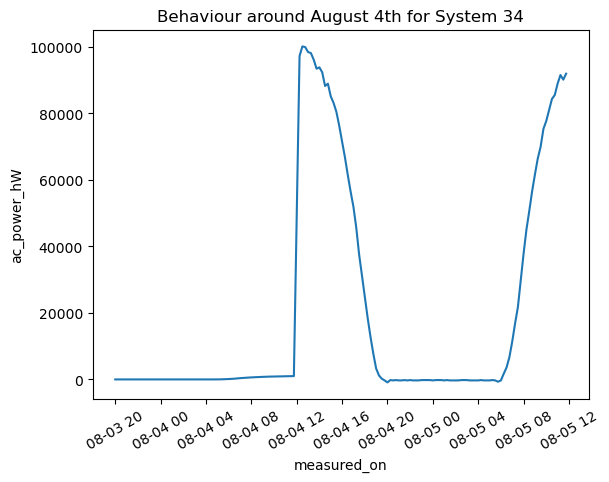

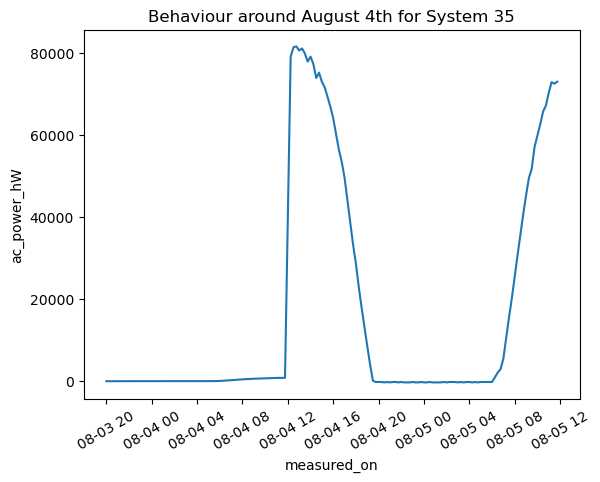

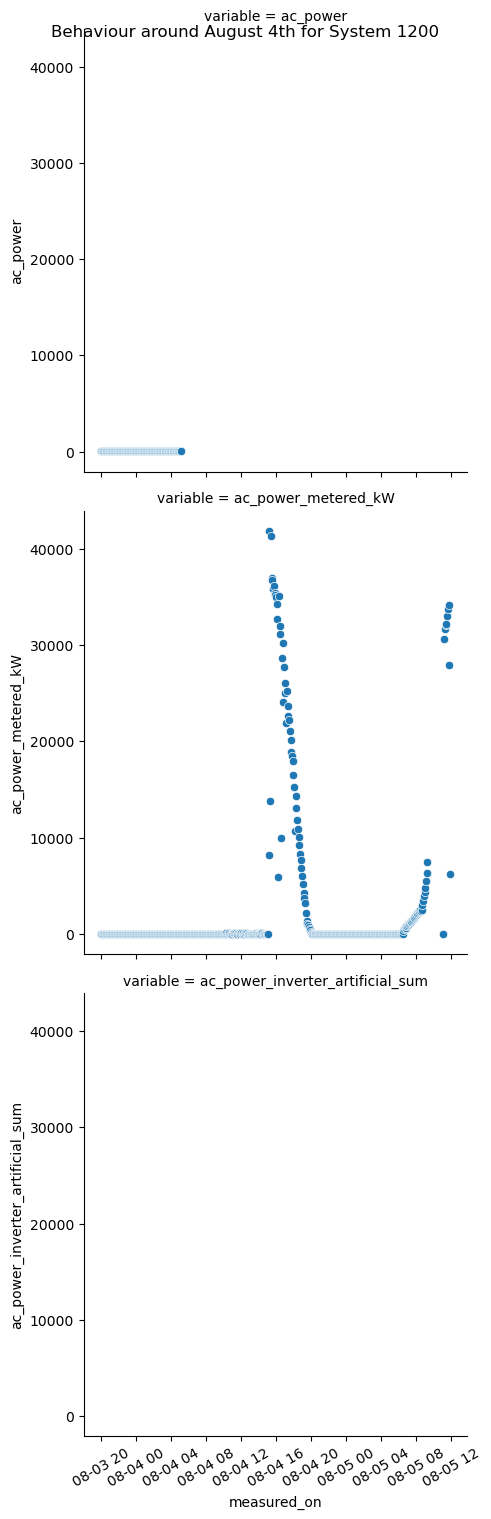

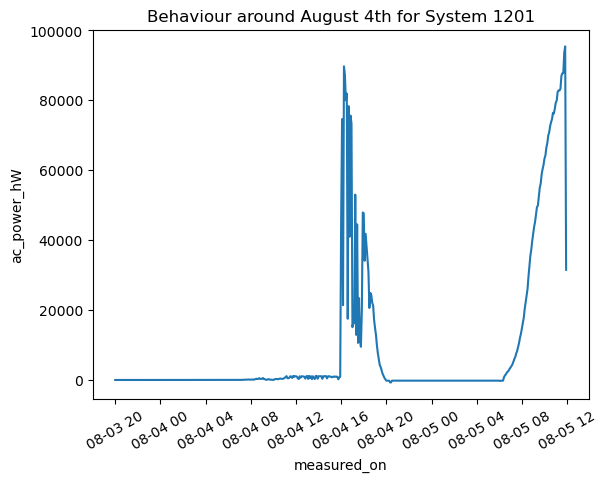

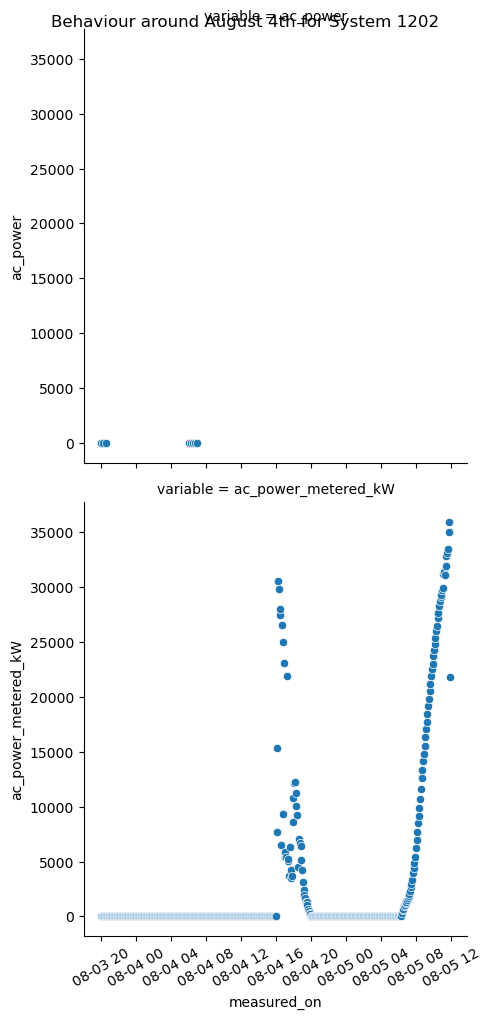

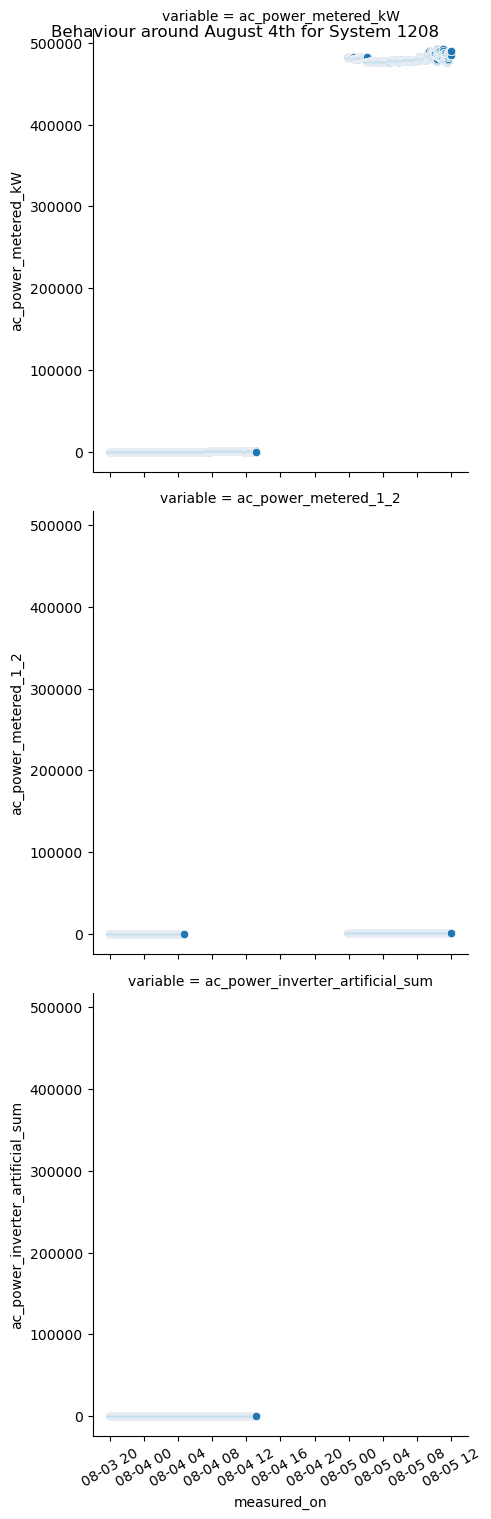

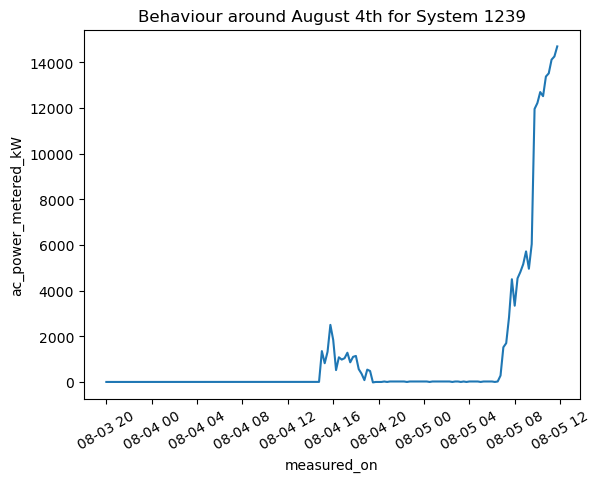

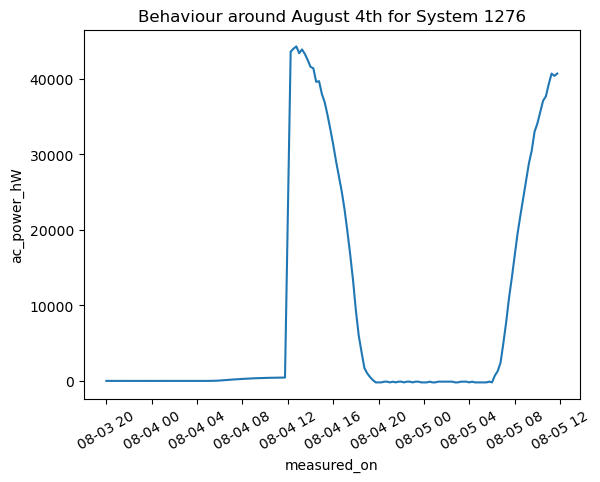

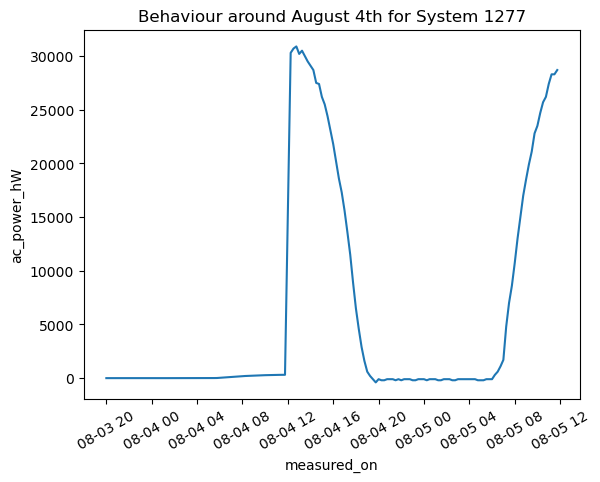

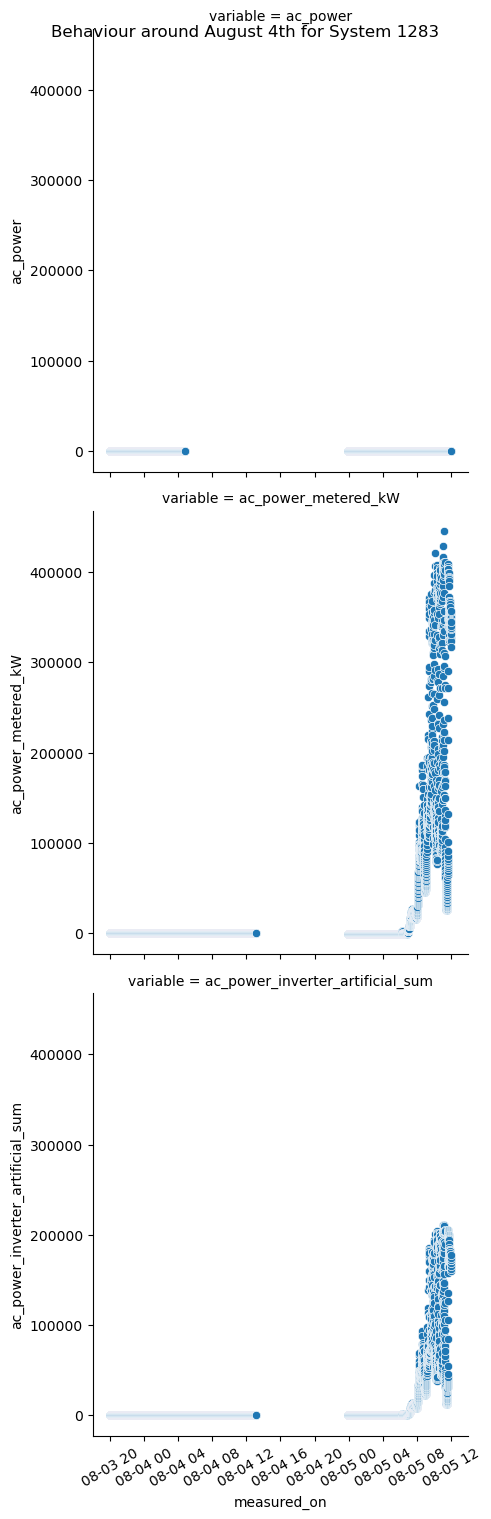

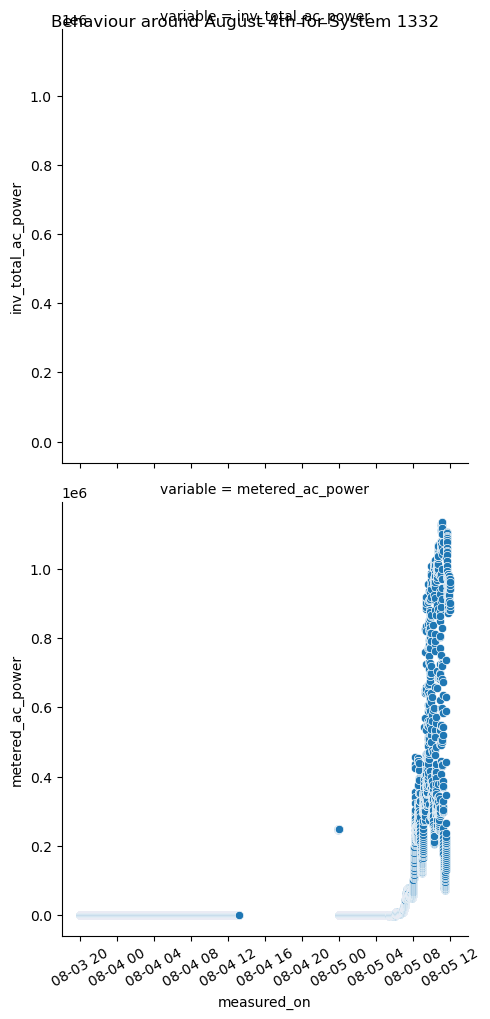

In [87]:
for system_id in switch_in_2018_systems:
    (my_metrics, my_metadata, my_data) = ac_power_gather_data(
        all_ac_pow_metrics=all_ac_power_names, all_ac_pow_metadata=all_ac_power_meta,
        system_id=system_id, error_on_no_data=True, add_aggs=True
    )
    whole_metrics_names = []
    for metric_dict in my_metrics:
        if metric_dict['whole_or_part'] == 'whole':
            whole_metrics_names.append(metric_dict['sensor_name'])
    my_data_restrict = my_data[(my_data['measured_on']>= datetime(2018, 8, 3, 20))
                               & (my_data['measured_on'] < datetime(2018, 8, 5, 12))]
    # make it 'tall' for plotting purposes
    my_data_restrict = pd.melt(
        my_data_restrict,
        id_vars = 'measured_on',
        value_vars = whole_metrics_names,
        var_name = 'variable',
        value_name = 'value'
    )
    my_data_restrict.reset_index()
    if len(whole_metrics_names) > 1:
        g = sns.relplot(data=my_data_restrict,
                    x='measured_on',
                    y='value',
                    row='variable')
        for j, ax in enumerate(g.axes.flat):
            ax.set(ylabel=whole_metrics_names[j])
            ax.tick_params('x', labelrotation = 30)
        plt.suptitle(f'Behaviour around August 4th for System {system_id}')
        plt.show()
    else:
        fig = plt.Figure()
        ax = sns.lineplot(data = my_data_restrict,
                     x = 'measured_on',
                     y = 'value')
        ax.set(ylabel=whole_metrics_names[0])
        ax.tick_params('x', labelrotation = 30)
        plt.title(f'Behaviour around August 4th for System {system_id}')
        plt.show()
    

Not as synchronized as at first glance:
Systems 34-35 change around noon.

System *1200*: `ac_power` goes to 8 am on Aug. 4 and stops.  `ac_power_metered_kW` changes 3-4 pm.

System 1201 -- again 3-4 pm.

System 1202: Like 1200, but `ac_power` is even less well tracked.

System 1208: `ac_power_metered_kW` goes away just after noon, returns just before midnight (4th-5th transfer)
`ac_power_metered_1_2` goes away early on the 4th, comes back on the 5th (roughly)
inverter sums go away noon-4 pm

System 1239 -- small spike starting 2-3 pm on the 4th, proper production on the 5th

Systems 1276-1277 -- again noon on the 4th

System *1283*: `ac_power` dropped on the 4th and briefly continued on the 5th
`ac_power_metered_kW` drops out around noon, to new-normal by the 5th
sum of inverter measure is the same.

System 1332 -- inverter data already missing
meter data down on the 4th and back on the 5th at the new scale.

Indeed, may want to just drop the data on the 4th for dropouts, and assume that 3rd & 5th are fine!

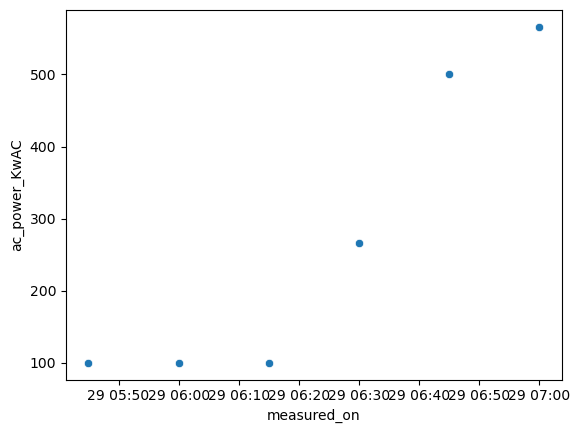

In [88]:
(my_metrics, my_metadata, my_data) = ac_power_gather_data(
    all_ac_pow_metrics=all_ac_power_names, all_ac_pow_metadata=all_ac_power_meta,
    system_id=1420, error_on_no_data=True, add_aggs=True
)
# get 2018 monthly averages
my_data_restrict = my_data[(my_data['measured_on'] >= datetime(2017, 3, 29, 5, 45))
                           & (my_data['measured_on'] < datetime(2017, 3, 29, 7, 1))]
sns.scatterplot(
    data = my_data_restrict,
    x = 'measured_on',
    y = 'ac_power_KwAC'
)
plt.show()

System 1420 shifts over sometime around 6:15 am on March 29th, 2017 (DST)

OK -- of the un-shifting systems, what is the unit-count likely to be?

In [111]:
def ac_power_units_tester(
    system_id: int,
    systems_cleaned: pd.DataFrame,
    print_warnings: bool = True,
):
    (my_metrics, my_metadata, my_data) = ac_power_gather_data(
        all_ac_pow_metrics=all_ac_power_names, all_ac_pow_metadata=all_ac_power_meta,
        system_id=system_id, error_on_no_data=True, add_aggs=True
    )
    whole_metrics_name_unit_pairs = dict()
    for metric_dict in my_metrics:
        if metric_dict['whole_or_part'] == 'whole':
            whole_metrics_name_unit_pairs[metric_dict['sensor_name']]\
            = metric_dict['units']
    # grab the good day
    is_good_date = False
    test_count = 1
    my_good_date = find_good_date(
        system_id=system_id,
        systems_cleaned=systems_cleaned,
        error_out=True
    )
    my_data['date'] = my_data['measured_on'].dt.date
    my_data_on_date = my_data[my_data['date'] == my_good_date]
    while not is_good_date:
        my_data['date'] = my_data['measured_on'].dt.date
        my_data_on_date = my_data[my_data['date'] == my_good_date]
        if my_data_on_date.shape[0] > 0:
            is_good_date = True
        else:
            test_count += 1
            my_good_date += timedelta(days=1)
            my_data_on_date = my_data[my_data['date'] == my_good_date]
            if test_count > 150:  # call it quits
                if print_warnings:
                    print(f'System {system_id} does not have any data on 150 test-days.')
                return None
    # find the kW incentive
    relevant_rows_systems = systems_cleaned[systems_cleaned['system_id'] == system_id]
    ind = relevant_rows_systems.index[0]
    my_dc_power_kW = relevant_rows_systems.loc[ind, 'dc_capacity_kW']
    # test each aggregator
    results = {
        name: True for name in whole_metrics_name_unit_pairs.keys()
    }
    for (name, unit) in whole_metrics_name_unit_pairs.items():
        max_data = my_data_on_date[name].max()
        if unit == 'W':
            max_data = max_data / 1000
        if my_dc_power_kW / max_data >= 10:
            if print_warnings:
                print(f'For System {system_id}, variable {name},\n',
                      f'units should be kW')
            results[name] = False
        elif (max_data/ my_dc_power_kW >= 10):
            raise ValueError(
                f'For System {system_id}, variable {name},\n',
                f'max val of {max_data} is far above {my_dc_power_kW}'
            )
        else:
            results[name] = True
    return results
    

In [56]:
for system_id in all_parquet_pow_ids:
    if (system_id not in switch_unit_systems) & (system_id != 1416):
        try:
            my_ac_power_names = deepcopy(all_ac_power_names[system_id])
            ac_power_units_tester(system_id=system_id, systems_cleaned=systems_cleaned)
        except KeyError:
            continue
        except BaseException as e:
            raise e

System 1262 does not have any data on 150 test-days.
For System 1275, variable ac_power_metered_kW,
 units should be kW
System 1306 does not have any data on 150 test-days.
System 1317 does not have any data on 150 test-days.
System 1322 does not have any data on 150 test-days.
For System 1430, variable ac_power,
 units should be kW
For System 1431, variable ac_power,
 units should be kW
For System 1432, variable ac_power,
 units should be kW
For System 1433, variable ac_power,
 units should be kW


Confirmed from looking at max-power data, Systems 1275, 1430-1433 identifications are (with high probability) accurate!

Remaining low-data systems [1262, 1306, 1317, 1322] are 1-2 year systems for which the units are probably accurate, regardless.

In [63]:
systems_cleaned[systems_cleaned.system_id.isin([1262, 1306, 1317, 1322])][['system_id', 'num_days_actual_records']]

,system_id,num_days_actual_records
51,1262,289
83,1306,404
93,1317,1
98,1322,2


In [67]:
all_ac_power_names[1322]

[{'metric_id': np.int32(274),
  'sensor_name': 'RTW',
  'common_name': 'AC power',
  'units': 'W',
  'calc_details': '',
  'whole_or_part': 'whole',
  'source_type': 'unknown'}]

In [54]:
two_years_days = 2 * 365
enough_data_systems = systems_cleaned[systems_cleaned['num_days_actual_records'] >= two_years_days]
enough_data_ids = set(enough_data_systems.system_id)
enough_data_parquet_power_systems = enough_data_ids.intersection(all_parquet_pow_ids)
enough_data_parquet_power_list = list(enough_data_parquet_power_systems)
enough_data_parquet_power_list.sort()

In [70]:
len(enough_data_parquet_power_systems)

86

In [71]:
for system_id in enough_data_parquet_power_list:
    if (system_id not in switch_unit_systems) & (system_id != 1416):
        try:
            my_ac_power_names = deepcopy(all_ac_power_names[system_id])
            ac_power_units_tester(system_id=system_id, systems_cleaned=systems_cleaned)
        except KeyError:
            continue
        except BaseException as e:
            raise e

For System 1275, variable ac_power_metered_kW,
 units should be kW
For System 1430, variable ac_power,
 units should be kW
For System 1431, variable ac_power,
 units should be kW
For System 1432, variable ac_power,
 units should be kW
For System 1433, variable ac_power,
 units should be kW


How many systems have competing aggregates (now that we have deliberately allowed the duplicates, temporarily)?

In [55]:
multiple_aggregators = []
for system_id in tqdm(all_parquet_pow_ids):
    try:
        my_ac_power_names = deepcopy(all_ac_power_names[system_id])
    except KeyError as e:
        continue
    except BaseException as e:
        raise e
    (my_ac_power_names_revised, _, _) = ac_power_gather_data(
        all_ac_pow_metrics=all_ac_power_names, all_ac_pow_metadata=all_ac_power_meta,
        system_id=system_id, error_on_no_data=True, add_aggs=True
    )
    whole_power_names = []
    for metric_dict in my_ac_power_names_revised:
        if metric_dict['whole_or_part'] == 'whole':
            whole_power_names.append(metric_dict['sensor_name'])
    if len(whole_power_names) > 1:
        multiple_aggregators.append(system_id)
multiple_aggregators

  1%|▏         | 2/156 [00:06<08:39,  3.37s/it]


KeyboardInterrupt: 

The pre-make-aggregates duplicates were sorted;
now we have aggregates for Systems 1200, 1202, 1203, 1208, 1283, 1332, 4901, 4902, 4903

In [73]:
for system_id in multiple_aggregators:
    (my_ac_power_names_revised, _, _) = ac_power_gather_data(
        all_ac_pow_metrics=all_ac_power_names, all_ac_pow_metadata=all_ac_power_meta,
        system_id=system_id, error_on_no_data=True, add_aggs=True
    )
    whole_power_names_and_types = dict()
    for metric_dict in my_ac_power_names_revised:
        if metric_dict['whole_or_part'] == 'whole':
            whole_power_names_and_types[metric_dict['sensor_name']] = metric_dict['source_type']
    print(system_id)
    print(whole_power_names_and_types)
    

4901
{'InvPAC_kW_Avg': 'inverter', 'PwrMtrP_kW_Avg': 'meter'}
4903
{'InvPAC_kW_Avg': 'inverter', 'PwrMtrP_kW_Avg': 'meter'}
1200
{'ac_power': 'meter', 'ac_power_metered_kW': 'meter', 'ac_power_inverter_artificial_sum': 'inverter'}
1202
{'ac_power': 'inverter', 'ac_power_metered_kW': 'meter'}
1203
{'ac_power': 'meter', 'ac_inverter_power': 'inverter'}
1208
{'ac_power_metered_kW': 'meter', 'ac_power_metered_1_2': 'meter', 'ac_power_inverter_artificial_sum': 'inverter'}
1283
{'ac_power': 'meter', 'ac_power_metered_kW': 'meter', 'ac_power_inverter_artificial_sum': 'inverter'}
4902
{'InvPAC_kW_Avg': 'inverter', 'PwrMtrP_kW_Avg': 'meter'}
1332
{'inv_total_ac_power': 'inverter', 'metered_ac_power': 'meter'}


Thus, all inverter-vs-meter issues, plus the three duplicates already shown.

### Automated Outlier Detection?

In [56]:
def outlier_year_detector(
    system_id: int,
    systems_cleaned: pd.DataFrame,
    outlier_multiplier = 2
):
    (my_metrics, _, my_data) = ac_power_gather_data(
        all_ac_pow_metrics=all_ac_power_names, all_ac_pow_metadata=all_ac_power_meta,
        system_id=system_id, error_on_no_data=True, add_aggs=True
    )
    whole_metrics_names = []
    for metric_dict in my_metrics:
        if metric_dict['whole_or_part'] == 'whole':
            whole_metrics_names.append(metric_dict['sensor_name'])
    # get yearly averages
    my_data['year'] = my_data['measured_on'].dt.year
    yearly_maxes = my_data.groupby('year').max()
    yearly_maxes = yearly_maxes.drop(columns='measured_on')
    outlier_names = []
    for col_name in yearly_maxes.columns:
        sorted_maxes = yearly_maxes[col_name].sort_values()
        if sorted_maxes.iloc[-1] >  outlier_multiplier * sorted_maxes.iloc[-2]:
            if sorted_maxes.iloc[-2] > 0:
                outlier_names.append((col_name, sorted_maxes.index[-1],
                                      sorted_maxes.iloc[-1] / sorted_maxes.iloc[-2]))
            else:
                outlier_names.append((col_name, sorted_maxes.index[-1],
                                      sorted_maxes.iloc[-1], sorted_maxes.iloc[-2]))
    if len(outlier_names) > 0:
        return outlier_names
    else:
        return False

In [131]:
for system_id in enough_data_parquet_power_list:
    try:
        my_ac_power_names = deepcopy(all_ac_power_names[system_id])
        outliers = outlier_year_detector(system_id=system_id, systems_cleaned=systems_cleaned,
                                         outlier_multiplier = 1.2)
        if outliers:
            print(f'System {system_id}')
            print(outliers)
    except KeyError:
        continue
    except BaseException as e:
        raise e

System 10
[('ac_power', np.int32(2011), np.float64(1.2058823529411764))]
System 33
[('ac_power', np.int32(2011), np.float64(2.696996625386858))]
System 36
[('ac_power', np.int32(2012), np.float64(1.6992006731173748))]
System 50
[('ac_power', np.int32(2004), np.float64(416.45136605605137))]
System 1289
[('ac_power', np.int32(2014), np.float64(1.7798411340656815))]
System 1422
[('ac_power_inverter_artificial_sum', np.int32(2016), np.float64(1.2448986431140763))]
System 1431
[('ac_power', np.int32(2016), np.float64(1.510874612147432))]
System 4903
[('InvPAC_kW_Avg', np.int32(2016), np.float64(2.405692039199893))]


Further study:

System 10 seems to have some frothy outliers above the official maximum of 1.12 kW = 1120 W; this particular one is Oct. 4th, 2011.

System 33's 2011 blip is a single dot out of place on Sept. 15, 2011.

System 36 has strange data on Sept. 28th, 2012.

System 50's 2004 data is bad data on October 11, 2004, 3pm - 11:59 pm

System 1289 has weird data on Oct. 7, 2014

System 1422 has somewhat frothy data after re-start in August 2016, and regular spikes for the rest of the year above the 3 kW - per - inverter system.

System 1431 has a single blip on Sept. 2, 2016 at about 2:30 pm

System 4903's bad data is on 10/6/2016, 5:30 - 6:00 am

Recommendation: apart from Systems 10 and 1422, can just delete a single day's data; the remainders require a cap or something.

Warning: did not detect the weird 1208 blip earlier.  Will try with a different strategy.

In [57]:
def outlier_year_detector_alt(
    system_id: int,
    systems_cleaned: pd.DataFrame,
    outlier_multiplier = 2
):
    (my_metrics, _, my_data) = ac_power_gather_data(
        all_ac_pow_metrics=all_ac_power_names, all_ac_pow_metadata=all_ac_power_meta,
        system_id=system_id, error_on_no_data=True, add_aggs=True
    )
    whole_metrics_names = []
    for metric_dict in my_metrics:
        if metric_dict['whole_or_part'] == 'whole':
            whole_metrics_names.append(metric_dict['sensor_name'])
    # get yearly averages
    my_data['year'] = my_data['measured_on'].dt.year
    yearly_maxes = my_data.groupby('year').max()
    yearly_maxes = yearly_maxes.drop(columns='measured_on')
    outlier_names = []
    for col_name in yearly_maxes.columns:
        col_maxes = yearly_maxes[col_name]
        if col_maxes.shape[0] >= 3:
            # start with index 0
            if col_maxes.iloc[0] > outlier_multiplier * col_maxes.iloc[1]:
                if col_maxes.iloc[1] > 0:
                    outlier_names.append((
                        col_name,
                        col_maxes.index[0], 'ratio',
                        col_maxes.iloc[0] / col_maxes.iloc[0 + 1] 
                    ))
                else:
                    outlier_names.append((
                        col_name,
                        col_maxes.index[0], 'value',
                        col_maxes.iloc[0],
                        col_maxes.iloc[1]
                    ))
            for j in range(1, col_maxes.shape[0] - 1):
                if (col_maxes.iloc[j] > outlier_multiplier * max(
                    col_maxes.iloc[j - 1], col_maxes.iloc[j + 1]
                )):
                    if (col_maxes.iloc[j - 1] > 0) and (col_maxes.iloc[j + 1] > 0):
                        outlier_names.append((col_name,
                            col_maxes.index[j], 'ratio',
                            col_maxes.iloc[j] / col_maxes.iloc[j - 1],
                            col_maxes.iloc[j] / col_maxes.iloc[j + 1] 
                        ))
                    else:
                        outlier_names.append((col_name,
                            col_maxes.index[j], 'value',
                            col_maxes.iloc[j - 1],
                            col_maxes.iloc[j],  col_maxes.iloc[j + 1] 
                        ))
            # last index
            if col_maxes.iloc[-1] > outlier_multiplier * col_maxes.iloc[-2]:
                if col_maxes.iloc[-2] > 0:
                    outlier_names.append((
                        col_name,
                        col_maxes.index[-1], 'ratio',
                        col_maxes.iloc[-1] / col_maxes.iloc[-2] 
                    ))
                else:
                    outlier_names.append((
                        col_name,
                        col_maxes.index[-1], 'value',
                        col_maxes.iloc[-2], col_maxes.iloc[-1] 
                    ))

        elif col_maxes.shape[0] == 2:
            if col_maxes.iloc[0] > outlier_multiplier * col_maxes.iloc[1]:
                if col_maxes.iloc[1] > 0:
                    outlier_names.append((
                        col_name, col_maxes.index[0], 
                        'ratio',
                        col_maxes.iloc[0] / col_maxes.iloc[1]
                    ))
                else:
                    outlier_names.append((col_name,
                        col_maxes.index[0], 'value',
                        col_maxes.iloc[0], col_maxes.iloc[1] 
                    ))
            elif col_maxes.iloc[1] > outlier_multiplier * col_maxes.iloc[0]:
                if col_maxes.iloc[0] > 0:
                    outlier_names.append((
                        col_name, col_maxes.index[1], 
                        'ratio',
                        col_maxes.iloc[1] / col_maxes.iloc[0]
                    ))
                else:
                    outlier_names.append((col_name,
                            col_maxes.index[1], 'value',
                            col_maxes.iloc[0], col_maxes.iloc[1] 
                    ))
                outlier_names.append((col_name, col_maxes.index[1], col_maxes.iloc[1] / col_maxes.iloc[0]))
    if len(outlier_names) > 0:
        return outlier_names
    else:
        return False

In [149]:
for system_id in enough_data_parquet_power_list:
    try:
        my_ac_power_names = deepcopy(all_ac_power_names[system_id])
        outliers = outlier_year_detector_alt(system_id=system_id, systems_cleaned=systems_cleaned,
                                         outlier_multiplier = 1.2)
        if outliers:
            print(f'System {system_id}')
            print(outliers)
    except KeyError:
        continue
    except BaseException as e:
        raise e

System 4
[('ac_power', np.int32(2010), 'ratio', np.float64(1.7630666619738138), np.float64(1.5710629140947958)), ('ac_power', np.int32(2012), 'ratio', np.float64(1.83122661358122), np.float64(1.8796929815540326)), ('ac_power', np.int32(2014), 'ratio', np.float64(1.6115508402050007), np.float64(1.599434637129341))]
System 10
[('ac_power', np.int32(2011), 'ratio', np.float64(1.2588108108108107), np.float64(1.2058823529411764))]
System 33
[('ac_power', np.int32(2011), 'ratio', np.float64(3.078234215426727), np.float64(2.710590567880699))]
System 36
[('ac_power', np.int32(2012), 'ratio', np.float64(1.8334089877439854))]
System 50
[('ac_power', np.int32(2004), 'ratio', np.float64(469.5317171679727), np.float64(512.3310086878862))]
System 1208
[('ac_power_inverter_artificial_sum', np.int32(2012), 'ratio', np.float64(129.40878614164006), np.float64(129.3781785334916))]
System 1289
[('ac_power', np.int32(2014), 'ratio', np.float64(1.7798411340656815), np.float64(1.786094849798855))]
System 132

System 4 -- bad days 2010-01-21, 2012-10-18, 2014-10-06

System 1208 -- single bad data point 2012-05-15

Systems 1321 and 1332 are just bad-data anomalies.

## The plan:

For each system:
1.  Grab the metadata list (now with the duplicative terms erased, now that we have a better idea of what's going on.)
2.  Grab data as usual.
3.  If fewer than 2 years of data, drop.
4.  If in switch-units set, convert to consistent kW at the appropriate times.
5.  If inaccurate W, update to kW.
6.  If accurate W, force change to kW.
7.  If in outliers group, and not 1422 (weirdly inconsistent), just drop the outlier-days.
8.  If fewer than 10 data points in a day, drop the day.
9.  Take daily means.
10. Save.

In [58]:
all_ac_power_names_slim, all_ac_power_meta_slim = find_all_ac_power_names(
    systems_cleaned=systems_cleaned,
    metrics_df=metrics_df,
    print_messages=False,
    drop_competing_meter_data=True 
)

In [59]:
switch_unit_systems = [34, 35, 1200, 1201, 1202, 1208,
                       1239, 1276, 1277, 1283, 1332, 1420]

Except for System 1332, `inv_total_ac_power`, it always switches large unit - W,
and in the exceptional case, there are only two valid points, so can delete the latter bit entirely.

In [60]:
switch_in_2018_systems = deepcopy(switch_unit_systems)
switch_in_2018_systems.pop(-1)
switch_in_2018_systems

[34, 35, 1200, 1201, 1202, 1208, 1239, 1276, 1277, 1283, 1332]

In [61]:
my_unit_shift_days = {
    system_id: date(2014, 8, 4) for system_id in switch_in_2018_systems
}
my_unit_shift_days[1420] = date(2017, 3, 29)
my_unit_shift_days

{34: datetime.date(2014, 8, 4),
 35: datetime.date(2014, 8, 4),
 1200: datetime.date(2014, 8, 4),
 1201: datetime.date(2014, 8, 4),
 1202: datetime.date(2014, 8, 4),
 1208: datetime.date(2014, 8, 4),
 1239: datetime.date(2014, 8, 4),
 1276: datetime.date(2014, 8, 4),
 1277: datetime.date(2014, 8, 4),
 1283: datetime.date(2014, 8, 4),
 1332: datetime.date(2014, 8, 4),
 1420: datetime.date(2017, 3, 29)}

In [84]:
def starting_ending_units(system_id: int, var_name: str):
    '''For systems that change their units midstream,
    what are the units?
    Manually checked against data for the 12 flagged systems.'''
    if 'hw' in var_name.lower():
        return ('hW', 'W')
    elif 'kw' in var_name.lower():
        return ('kW', 'W')
    elif (
        (system_id == 1208 and 'inv' in var_name.lower())
        or (system_id == 1332 and 'meter' in var_name.lower())
        or (system_id == 1283 and 'inv' in var_name.lower())
    ):
        return ('kW', 'W')
    elif (
        (system_id == 1200 and 'inv' in var_name.lower())
        or (system_id == 1202 and var_name == 'ac_power')
        or (system_id == 1332 and 'inv' in var_name.lower())
    ):
        return ('W', None)
    else:
        raise ValueError('Case not accounted for.')

In [112]:
def units_normalizer(
    ac_pow_names,
    ac_pow_metadata: pd.DataFrame,
    system_id: int,
    systems_cleaned: pd.DataFrame,
    unit_shift_days,
):
    # grab the data
    (my_rev_pow_names, my_rev_pow_metadata, my_data) = ac_power_gather_data(
        ac_pow_names,
        ac_pow_metadata,
        system_id,
        True,
        True
    )
    # normalize units to kW, starting with the switching systems
    if system_id in unit_shift_days.keys():
        right_date = unit_shift_days[system_id]
        end_old_time = datetime(right_date.year, right_date.month, right_date.day, 0, 0)
        start_new_time = end_old_time + timedelta(days=1)
        my_data_early = my_data[my_data['measured_on'] < end_old_time]
        my_data_late = my_data[my_data['measured_on'] >= start_new_time]
        # this already drops the questionable day.  But must convert units before and after
        for metric_dict in my_rev_pow_names:
            # only have the 'whole' columns to work with
            if metric_dict['whole_or_part'] == 'whole':
                sensor_name = metric_dict['sensor_name']
                (early_unit, late_unit) = starting_ending_units(system_id, sensor_name)
                if early_unit == 'hW':
                    my_data_early[sensor_name] = my_data_early[sensor_name] / 10
                elif early_unit == 'W':
                    my_data_early[sensor_name] = my_data_early[sensor_name] / 1000
                # if early_unit = kW, nothing to do
                if late_unit is None:
                    my_data_late[sensor_name] = pd.NA
                elif late_unit == 'W':
                    my_data_late[sensor_name] = my_data_late[sensor_name] / 1000
                # if late_unit = kW, nothing to do.
                metric_dict['units'] = 'kW'
        my_data = pd.concat([my_data_early, my_data_late])
    else:
        # run the unit-accuracy subroutine
        unit_accuracy = ac_power_units_tester(system_id, systems_cleaned, False)
        if unit_accuracy is None:
            raise ValueError(f'For System {system_id}, not a good units reading!')
        for metric_dict in my_rev_pow_names:
            if metric_dict['whole_or_part'] == 'whole':
                sensor_name = metric_dict['sensor_name']
                unit = metric_dict['units']
                if unit == 'W':
                    if unit_accuracy[sensor_name]:
                        # True units are indeed W, but should be kW
                        my_data[sensor_name] = my_data[sensor_name] / 1000
                    # if False, true value kW, nothing to do.
                    metric_dict['units'] = 'kW'
                elif unit == 'kW':
                    if not unit_accuracy[sensor_name]:
                        # truly W, must convert to kW
                        my_data[sensor_name] = my_data[sensor_name] / 1000
                    # if kW accurate, nothing to do.
    # return the revised data
    return (my_rev_pow_names, my_rev_pow_metadata, my_data)

In [81]:
(my_1200_names, my_1200_meta, my_1200_data) = units_normalizer(all_ac_power_names_slim, all_ac_power_meta_slim, 1200, systems_cleaned, my_unit_shift_days)

In [86]:
(my_10_names, my_10_meta, my_10_data) = units_normalizer(all_ac_power_names_slim, all_ac_power_meta_slim, 10, systems_cleaned, my_unit_shift_days)

In [88]:
my_10_data.max()


measured_on    2023-02-28 23:59:00
ac_power                    1.7466
dtype: object

In [95]:
(my_1275_names, my_1275_meta, my_1275_data) = units_normalizer(all_ac_power_names_slim, all_ac_power_meta_slim, 1275, systems_cleaned, my_unit_shift_days)

For System 1275, variable ac_power_metered_kW,
 units should be kW


In [96]:
my_1275_data.max()


measured_on            2013-05-14 04:00:00
ac_power_metered_kW                 26.746
dtype: object

In [97]:
for system_id in switch_unit_systems:
    (_, _, my_data) = units_normalizer(all_ac_power_names_slim, all_ac_power_meta_slim, system_id, systems_cleaned, my_unit_shift_days)
    print(system_id)
    print(my_data.mean())
    print('')

34

measured_on    2015-08-23 03:38:05.272453632
ac_power_hW                         15.49824
dtype: object

35

measured_on    2015-06-29 13:03:24.379607040
ac_power_hW                        12.131597
dtype: object

1200

measured_on                         2016-06-05 09:32:08.831421440
ac_power_metered_kW                                      2.710505
ac_power_inverter_artificial_sum                        14.519695
dtype: object



KeyboardInterrupt: 

In [85]:
for system_id in [1332, 1420]:
    (_, _, my_data) = units_normalizer(all_ac_power_names_slim, all_ac_power_meta_slim, system_id, systems_cleaned, my_unit_shift_days)
    print(system_id)
    print(my_data.mean())
    print('')

1332

measured_on           2017-09-15 01:30:49.423665664
inv_total_ac_power                       169.901021
metered_ac_power                          80.619925
dtype: object

1420

measured_on      2017-04-12 18:43:39.654744576
ac_power_KwAC                         6.660883
dtype: object



In [99]:
for system_id in enough_data_parquet_power_list:
    try:
        my_ac_power_names = deepcopy(all_ac_power_names_slim[system_id])
        if system_id not in switch_unit_systems:
            (_, _, my_data) = units_normalizer(all_ac_power_names_slim, all_ac_power_meta_slim, system_id, systems_cleaned, my_unit_shift_days)
            print(system_id)
            print(my_data.mean())
            print('')
    except KeyError:
        continue
    except BaseException as e:
        raise e

4

measured_on    2016-07-12 16:00:27.525078016
ac_power                            0.161224
dtype: object

10

measured_on    2016-05-19 08:02:04.016854784
ac_power                            0.192032
dtype: object

33

measured_on    2016-12-09 20:08:11.537903616
ac_power                            0.412226
dtype: object

36

measured_on    2015-09-06 01:41:37.027636480
ac_power                            0.299011
dtype: object

50

measured_on    2016-01-02 04:26:02.464643840
ac_power                             1.07562
dtype: object

51

measured_on    2016-10-20 07:00:22.686766080
ac_power                            0.880761
dtype: object

1199

measured_on    2015-11-14 18:20:59.275608576
ac_power                           15.525274
dtype: object

1203

measured_on          2016-03-28 20:21:03.174733568
ac_power                                 28.543802
ac_inverter_power                        28.580103
dtype: object

1204

measured_on    2014-07-22 19:45:58.142087680
ac_power   

### Removal of known outliers -- verified bad days

System 4 -- bad days 2010-01-21, 2012-10-18, 2014-10-06

System 10 seems to have some frothy outliers above the official maximum of 1.12 kW = 1120 W; this particular one is Oct. 4th, 2011.

System 33's 2011 blip is a single dot out of place on Sept. 15, 2011.

System 36 has strange data on Sept. 28th, 2012.

System 50's 2004 data is bad data on October 11, 2004, 3pm - 11:59 pm

System 1208 -- single bad data point 2012-05-15

System 1289 has weird data on Oct. 7, 2014

Systems 1321 and 1332 are just bad-data anomalies.

System 1422 has somewhat frothy data after re-start in August 2016, and regular spikes for the rest of the year above the 3 kW - per - inverter system.

System 1431 has a single blip on Sept. 2, 2016 at about 2:30 pm

System 4903's bad data is on 10/6/2016, 5:30 - 6:00 am

Recommendation: apart from Systems 10 and 1422, can just delete a single day's data.

In [101]:
outlier_days = {
    4: [date(2010, 1, 21), date(2012, 10, 18), date(2014,10,6)],
    10: [date(2011, 10, 4)],
    33: [date(2011, 9, 15)],
    36: [date(2012, 9, 28)],
    50: [date(2004, 10, 11)],
    1208: [date(2012, 5, 15)],
    1289: [date(2014, 10, 7)],
    1431: [date(2016, 9, 2)],
    4903: [date(2016, 10, 6)]
}

In [108]:
def outliers_removal(
    units_cleaned_data: pd.DataFrame,
    system_id: int,
    outlier_days_list
):
    if system_id in outlier_days_list.keys():
        for bad_day in outlier_days_list[system_id]:
            end_old_datetime = datetime(bad_day.year, bad_day.month, bad_day.day, 0, 0)
            start_new_datetime = end_old_datetime + timedelta(days=1)
            excluded_data = units_cleaned_data[
                (units_cleaned_data.measured_on >= end_old_datetime)
                & (units_cleaned_data.measured_on < start_new_datetime)
            ]
            units_cleaned_data = units_cleaned_data.drop(
                index=excluded_data.index
            )
    return units_cleaned_data

Need a variant outlier detector to check if the cleaned data is good.

In [104]:
def outlier_year_detector_mod(
    my_metrics,
    my_data,
    system_id: int,
    outlier_multiplier = 2
):
    whole_metrics_names = []
    for metric_dict in my_metrics:
        if metric_dict['whole_or_part'] == 'whole':
            whole_metrics_names.append(metric_dict['sensor_name'])
    # get yearly averages
    my_data['year'] = my_data['measured_on'].dt.year
    yearly_maxes = my_data.groupby('year').max()
    yearly_maxes = yearly_maxes.drop(columns='measured_on')
    outlier_names = []
    for col_name in yearly_maxes.columns:
        sorted_maxes = yearly_maxes[col_name].sort_values()
        if sorted_maxes.iloc[-1] >  outlier_multiplier * sorted_maxes.iloc[-2]:
            if sorted_maxes.iloc[-2] > 0:
                outlier_names.append((col_name, sorted_maxes.index[-1],
                                      sorted_maxes.iloc[-1] / sorted_maxes.iloc[-2]))
            else:
                outlier_names.append((col_name, sorted_maxes.index[-1],
                                      sorted_maxes.iloc[-1], sorted_maxes.iloc[-2]))
    if len(outlier_names) > 0:
        return outlier_names
    else:
        return False

In [103]:
def outlier_year_detector_alt_mod(
    my_metrics,
    my_data,
    system_id: int,
    outlier_multiplier = 2
):
    whole_metrics_names = []
    for metric_dict in my_metrics:
        if metric_dict['whole_or_part'] == 'whole':
            whole_metrics_names.append(metric_dict['sensor_name'])
    # get yearly averages
    my_data['year'] = my_data['measured_on'].dt.year
    yearly_maxes = my_data.groupby('year').max()
    yearly_maxes = yearly_maxes.drop(columns='measured_on')
    outlier_names = []
    for col_name in yearly_maxes.columns:
        col_maxes = yearly_maxes[col_name]
        if col_maxes.shape[0] >= 3:
            # start with index 0
            if col_maxes.iloc[0] > outlier_multiplier * col_maxes.iloc[1]:
                if col_maxes.iloc[1] > 0:
                    outlier_names.append((
                        col_name,
                        col_maxes.index[0], 'ratio',
                        col_maxes.iloc[0] / col_maxes.iloc[0 + 1] 
                    ))
                else:
                    outlier_names.append((
                        col_name,
                        col_maxes.index[0], 'value',
                        col_maxes.iloc[0],
                        col_maxes.iloc[1]
                    ))
            for j in range(1, col_maxes.shape[0] - 1):
                if (col_maxes.iloc[j] > outlier_multiplier * max(
                    col_maxes.iloc[j - 1], col_maxes.iloc[j + 1]
                )):
                    if (col_maxes.iloc[j - 1] > 0) and (col_maxes.iloc[j + 1] > 0):
                        outlier_names.append((col_name,
                            col_maxes.index[j], 'ratio',
                            col_maxes.iloc[j] / col_maxes.iloc[j - 1],
                            col_maxes.iloc[j] / col_maxes.iloc[j + 1] 
                        ))
                    else:
                        outlier_names.append((col_name,
                            col_maxes.index[j], 'value',
                            col_maxes.iloc[j - 1],
                            col_maxes.iloc[j],  col_maxes.iloc[j + 1] 
                        ))
            # last index
            if col_maxes.iloc[-1] > outlier_multiplier * col_maxes.iloc[-2]:
                if col_maxes.iloc[-2] > 0:
                    outlier_names.append((
                        col_name,
                        col_maxes.index[-1], 'ratio',
                        col_maxes.iloc[-1] / col_maxes.iloc[-2] 
                    ))
                else:
                    outlier_names.append((
                        col_name,
                        col_maxes.index[-1], 'value',
                        col_maxes.iloc[-2], col_maxes.iloc[-1] 
                    ))

        elif col_maxes.shape[0] == 2:
            if col_maxes.iloc[0] > outlier_multiplier * col_maxes.iloc[1]:
                if col_maxes.iloc[1] > 0:
                    outlier_names.append((
                        col_name, col_maxes.index[0], 
                        'ratio',
                        col_maxes.iloc[0] / col_maxes.iloc[1]
                    ))
                else:
                    outlier_names.append((col_name,
                        col_maxes.index[0], 'value',
                        col_maxes.iloc[0], col_maxes.iloc[1] 
                    ))
            elif col_maxes.iloc[1] > outlier_multiplier * col_maxes.iloc[0]:
                if col_maxes.iloc[0] > 0:
                    outlier_names.append((
                        col_name, col_maxes.index[1], 
                        'ratio',
                        col_maxes.iloc[1] / col_maxes.iloc[0]
                    ))
                else:
                    outlier_names.append((col_name,
                            col_maxes.index[1], 'value',
                            col_maxes.iloc[0], col_maxes.iloc[1] 
                    ))
                outlier_names.append((col_name, col_maxes.index[1], col_maxes.iloc[1] / col_maxes.iloc[0]))
    if len(outlier_names) > 0:
        return outlier_names
    else:
        return False

In [109]:
for system_id in enough_data_parquet_power_list:
    try:
        my_ac_power_names = deepcopy(all_ac_power_names_slim[system_id])
        if system_id not in switch_unit_systems:
            (my_metrics, _, my_data) = units_normalizer(all_ac_power_names_slim, all_ac_power_meta_slim, system_id, systems_cleaned, my_unit_shift_days)
            my_data = outliers_removal(my_data, system_id, outlier_days)
            outliers_type_A = outlier_year_detector_mod(my_metrics, my_data, system_id, 1.2)
            outliers_type_B = outlier_year_detector_alt_mod(my_metrics, my_data, system_id, 1.2)
            if outliers_type_A or outliers_type_B:
                print(system_id)
                print(outliers_type_A)
                print(outliers_type_B)
                print('')
    except KeyError:
        continue
    except BaseException as e:
        raise e

For System 1275, variable ac_power_metered_kW,
 units should be kW
1321
False
[('RTW', np.int32(2017), 'value', np.float64(0.0), np.float64(0.6763828999999999), np.float64(0.0))]

1422
[('ac_power_inverter_artificial_sum', np.int32(2016), np.float64(1.244898643114076))]
[('ac_power_inverter_artificial_sum', np.int32(2016), 'ratio', np.float64(1.401983183580301), np.float64(1.244898643114076))]

For System 1430, variable ac_power,
 units should be kW
For System 1431, variable ac_power,
 units should be kW
For System 1432, variable ac_power,
 units should be kW
For System 1433, variable ac_power,
 units should be kW


In [110]:
for system_id in switch_unit_systems:
    try:
        my_ac_power_names = deepcopy(all_ac_power_names_slim[system_id])
        (my_metrics, _, my_data) = units_normalizer(all_ac_power_names_slim, all_ac_power_meta_slim, system_id, systems_cleaned, my_unit_shift_days)
        my_data = outliers_removal(my_data, system_id, outlier_days)
        outliers_type_A = outlier_year_detector_mod(my_metrics, my_data, system_id, 1.2)
        outliers_type_B = outlier_year_detector_alt_mod(my_metrics, my_data, system_id, 1.2)
        if outliers_type_A or outliers_type_B:
            print(system_id)
            print(outliers_type_A)
            print(outliers_type_B)
            print('')
    except KeyError:
        continue
    except BaseException as e:
        raise e

As good as it can get.

In [129]:
def ac_power_daily_avg_name(source_type: str):
    '''Make the standardized variable name.'''
    total_name = 'ac_power'
    if (source_type is not None) and (source_type != 'unknown'):
        total_name = total_name + '_' + source_type
    total_name = total_name + '_kW_daily_average'
    return total_name

def ac_power_daily_count(source_type: str):
    total_name = 'ac_power'
    if (source_type is not None) and (source_type != 'unknown'):
        total_name = total_name + '_' + source_type
    total_name = total_name + '_num_observations'
    return total_name

In [ ]:
def daily_cleaned_averages(
    my_metrics,
    my_data: pd.DataFrame,
    system_id: int,
    systems_cleaned: pd.DataFrame,
    null_or_zero: str = 'null'
):
    # grab official max. value.
    relevant_rows_systems = systems_cleaned[systems_cleaned['system_id'] == system_id]
    first_index = relevant_rows_systems.index[0]
    max_dc_capacity = relevant_rows_systems.loc[first_index, 'dc_capacity_kW']
    # prepare renaming dictionary for everything except measured_on
    renamer_dict = {
        col_name: '' for col_name in my_data.columns[1:]
    }
    # find date
    my_data['date'] = my_data['measured_on'].dt.date
    # clean too-small data
    for metric_dict in my_metrics:
        if metric_dict['whole_or_part'] == 'whole':
            sensor_name = metric_dict['sensor_name']
            source_type = metric_dict['source_type']
            this_var_max = my_data[sensor_name].max()
            smaller_max = min(max_dc_capacity, this_var_max)
            lower_bound = 0.01 * smaller_max
            if null_or_zero == 'null':
                my_data[sensor_name] = my_data.apply(
                    lambda row: row[sensor_name]
                    if (row[sensor_name] is not pd.NA
                        and row[sensor_name] >= lower_bound)
                    else pd.NA,
                    axis = 1
                )
            elif null_or_zero == 'zero':
                my_data[sensor_name] = my_data.apply(
                    lambda row: row[sensor_name]
                    if (row[sensor_name] is not pd.NA
                        and row[sensor_name] >= lower_bound)
                    else 0,
                    axis = 1
                )
            else:
                raise ValueError(f'null_or_zero is neither: {null_or_zero}')
            renamer_dict[sensor_name] = ac_power_daily_avg_name(source_type)
            # for debugging, count # of days
            my_data[ac_power_daily_count(source_type)] = my_data.groupby('date')[sensor_name].transform('count')
    # drop 'measured_on' now that we have date
    my_data = my_data.drop(columns = 'measured_on')
    # take daily averages
    avg_data = my_data.groupby('date').mean()
    avg_data = avg_data.reset_index()
    # rename
    avg_data = avg_data.rename(columns=renamer_dict)
    return avg_data

In [131]:
(my_1200_names, my_1200_meta, my_1200_data) = units_normalizer(all_ac_power_names_slim, all_ac_power_meta_slim, 1200, systems_cleaned, my_unit_shift_days)
my_1200_data = outliers_removal(my_1200_data, 1200, outlier_days)
my_1200_avgs = daily_cleaned_averages(my_1200_names, my_1200_data, system_id, systems_cleaned)

In [135]:
for system_id in enough_data_parquet_power_list:
    try:
        my_ac_power_names = deepcopy(all_ac_power_names_slim[system_id])
        (my_metrics, _, my_data) = units_normalizer(all_ac_power_names_slim, all_ac_power_meta_slim, system_id, systems_cleaned, my_unit_shift_days)
        my_data = outliers_removal(my_data, system_id, outlier_days)
        my_avgs = daily_cleaned_averages(my_metrics, my_data, system_id, systems_cleaned)
        print(system_id)
        print(my_avgs.shape)
        print('')
    except KeyError:
        continue
    except BaseException as e:
        raise e

4
(5060, 2)

10
(5885, 2)

33
(4421, 2)

34
(3557, 2)

35
(3533, 2)

36
(2514, 2)

50
(8453, 2)

51
(8029, 2)

1199
(3706, 2)

1200
(3354, 4)

1201
(3471, 2)

1202
(3482, 4)

1203
(3473, 4)

1204
(2498, 2)

1208
(3587, 4)

1214
(1326, 2)

1217
(1330, 2)

1219
(1330, 2)

1221
(1330, 2)

1223
(1330, 2)

1225
(1330, 2)

1231
(1903, 2)

1239
(3211, 2)

1244
(1193, 2)

1246
(1292, 2)

1248
(1291, 2)

1249
(780, 2)

1250
(1504, 2)

1252
(1286, 2)

1253
(1355, 2)

1254
(845, 2)

1255
(1297, 2)

1256
(959, 2)

1257
(1298, 2)

1258
(1085, 2)

1261
(835, 2)

1263
(1239, 2)

1264
(1274, 2)

1265
(1239, 2)

1266
(1274, 2)

1268
(1169, 2)

1269
(1200, 2)

1270
(1286, 2)

1271
(1255, 2)

1272
(1351, 2)

1273
(1376, 2)

1274
(774, 2)

1275
(984, 2)

1276
(3197, 2)

1277
(3138, 2)

1278
(3251, 2)

1283
(3394, 4)

1284
(991, 2)

1289
(2638, 2)

1300
(1395, 2)

1307
(1312, 2)

1308
(1400, 2)

1310
(1413, 2)

1314
(921, 2)

1318
(1472, 2)

1319
(1129, 2)

1321
(1546, 2)

1325
(1750, 2)

1326
(1232, 2)

1

In [133]:
my_1200_avgs.tail()

,ac_power_meter_kW_daily_average,ac_power_inverter_kW_daily_average,ac_power_meter_num_observations,ac_power_inverter_num_observations
date,,,,
2020-07-22,18.668164,NaN,122.0,0.0
2020-07-23,19.064314,NaN,153.0,0.0
2020-07-24,11.587564,NaN,156.0,0.0
2020-07-25,17.195951,NaN,163.0,0.0
2020-07-26,21.28448,NaN,125.0,0.0


In [119]:
bool(np.nan)

True

In [124]:
bool(np.nan >= 0.5)

False

In [120]:
bool(pd.NA)

TypeError: boolean value of NA is ambiguous

## Testing ground -- Can ignore after this.

#### System 10

In [132]:
system_id = 10
relevant_rows_metrics = metrics_df[metrics_df['system_id'] == system_id]
metrics_search_for_two_fragments_df(relevant_rows_metrics, 'pow', 'ac', 'and')

,system_id,metric_id,sensor_name,common_name,raw_units,units,calc_scale,calc_offset,calc_details,aggregation_type,source_type,source_id,comments,standard_name
1,10,423,ac_power,AC power,W,W,1.0,0.0,,avg,NaN,NaN,,ac_power__423


In [133]:
path_10 = Path(f'../../../../data_ds_project/systems/parquet/10/')
pq_10  = pq.ParquetDataset(
    path_10, filters=[
            ('metric_id', 'in', [423])
    ]
)
df_10 = pq_10.read().to_pandas()
df_10 = df_10.drop_duplicates()
df_10.head()

,measured_on,utc_measured_on,metric_id,value
0,2000-04-23 09:25:00,NaT,423,-9.1437
1,2000-05-03 00:12:00,NaT,423,-108.4500
2,2000-05-10 09:01:00,NaT,423,-107.1200
3,2000-05-10 09:11:00,NaT,423,-106.7200
4,2000-05-10 09:36:00,NaT,423,-107.7900


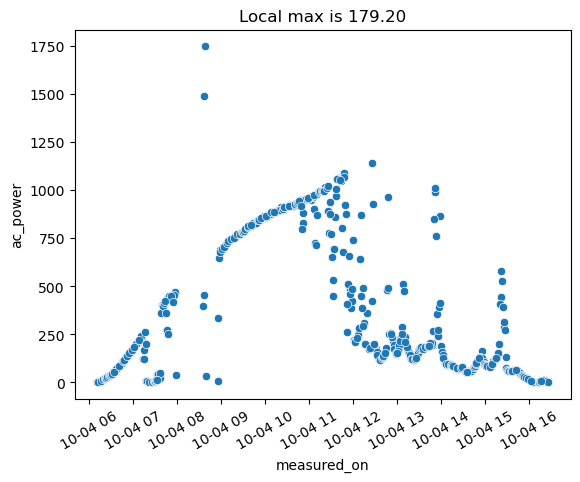

In [ ]:
df_10_2011 = df_10[df_10['measured_on'].dt.year==2011]
df_10_2011_pos = df_10_2011[df_10_2011['value'] > 0.02]
df_10_2011_local = df_10_2011_pos[
    (df_10_2011_pos['measured_on'] >= datetime(2011, 10, 4))
    & (df_10_2011_pos['measured_on'] < datetime(2011, 10, 5))
]
df_10_2011_local_max = df_10_2011_local['value'].max()
ax = sns.scatterplot(
    data = df_10_2011_local,
    x = 'measured_on',
    y = 'value'
)
ax.set(ylabel='ac_power')
ax.tick_params('x', labelrotation=30)
plt.title(f'Local max is {df_10_2011_local_max:.2f}')
plt.show()

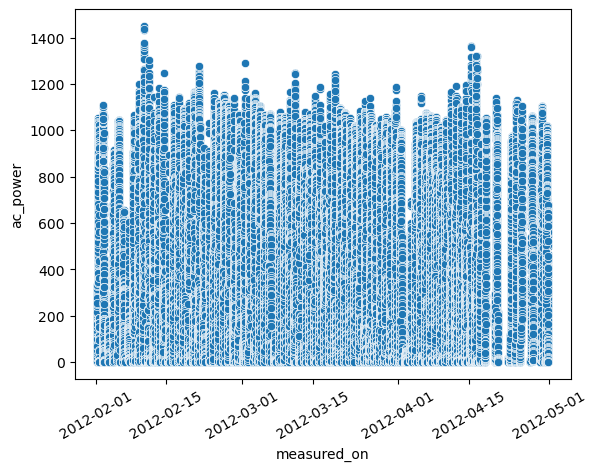

In [140]:
df_10_2012 = df_10[df_10['measured_on'].dt.year==2012]
df_10_2012_pos = df_10_2012[df_10_2012['value'] > 0.02]
df_10_2012_local = df_10_2012_pos[
    (df_10_2012_pos['measured_on'] >= datetime(2012, 2, 1))
    & (df_10_2012_pos['measured_on'] < datetime(2012, 5, 1))
]
ax = sns.scatterplot(
    data = df_10_2012_local,
    x = 'measured_on',
    y = 'value'
)
ax.set(ylabel='ac_power')
ax.tick_params('x', labelrotation=30)
plt.show()

In [141]:
systems_cleaned[systems_cleaned['system_id'] == 10]

,system_id,system_public_name,site_location,timezone_or_utc_offset,latitude,longitude,elevation_m,dc_capacity_kW,kg_climate,pvcz_composite,...,has_power_data,has_current_data,has_voltage_data,has_ac_data,has_dc_data,module_type,simplified_type,system_source,num_days_actual_records,sample_year
3,10,NREL CIS -1,"Golden, CO",7,39.7404,-105.1774,1792.8,1.12,BSk,12,...,True,True,True,True,True,cis family thin-film,thin_film,PVDAQ General,5893,2007


In [172]:
df_10['value'].describe()

count    6.654660e+06
mean     1.919639e+02
std      3.088520e+02
min     -1.509200e+02
25%     -7.641200e-01
50%     -1.429000e-01
75%      2.978600e+02
max      1.746600e+03
Name: value, dtype: float64

In [173]:
df_10_trimmed = df_10[df_10['value']>20]

In [176]:
df_10_trimmed['year'] = df_10_trimmed['measured_on'].dt.year
df_10_trimmed.groupby(['year'])['value'].max()

year
2000     248.57
2006    1239.40
2007    1243.90
2008    1164.40
2009    1263.40
2010    1387.50
2011    1746.60
2012    1448.40
2013    1364.00
2014    1441.90
2015    1400.80
2016    1378.20
2017    1315.00
2018    1330.10
2019    1339.50
2020    1276.50
2021    1294.40
2022    1243.20
2023    1153.90
Name: value, dtype: float64

(Apart from the weird 2000 data, this is OK!  Too close to 0.)

KeyboardInterrupt: 

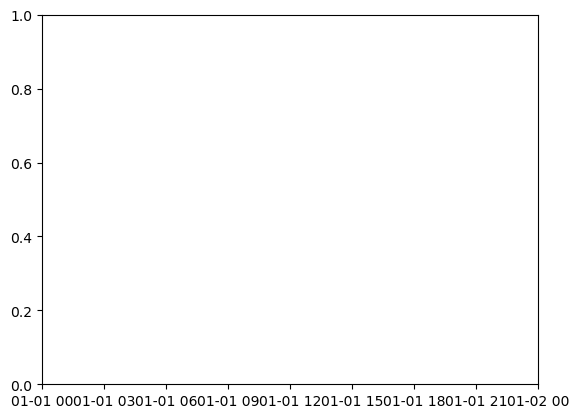

In [174]:
sns.lineplot(
    data = df_10_trimmed,
    x = 'measured_on',
    y = 'value'
)
plt.ylabel('AC Power')
plt.show()

### System 33

In [81]:
system_id = 33
relevant_rows_metrics = metrics_df[metrics_df['system_id'] == system_id]
metrics_search_for_two_fragments_df(relevant_rows_metrics, 'pow', 'ac', 'and')

,system_id,metric_id,sensor_name,common_name,raw_units,units,calc_scale,calc_offset,calc_details,aggregation_type,source_type,source_id,comments,standard_name
1305,33,584,ac_power,AC power,W,W,1.0,0.0,,avg,NaN,NaN,,ac_power__584
1318,33,596,power_factor,AC other,-,-,1.0,0.0,,NaN,NaN,NaN,,power_factor__596


In [82]:
path_33 = Path(f'../../../../data_ds_project/systems/parquet/33/')
pq_33  = pq.ParquetDataset(
    path_33, filters=[
            ('metric_id', 'in', [584])
    ]
)
df_33 = pq_33.read().to_pandas()
df_33 = df_33.drop_duplicates()
df_33.tail()

,measured_on,utc_measured_on,metric_id,value
6265970,2023-02-28 23:40:00,2023-03-01 06:40:00,584,6.564929
6265971,2023-02-28 23:41:00,2023-03-01 06:41:00,584,6.553329
6265972,2023-02-28 23:42:00,2023-03-01 06:42:00,584,6.566298
6265973,2023-02-28 23:43:00,2023-03-01 06:43:00,584,6.523714
6265974,2023-02-28 23:44:00,2023-03-01 06:44:00,584,6.557863


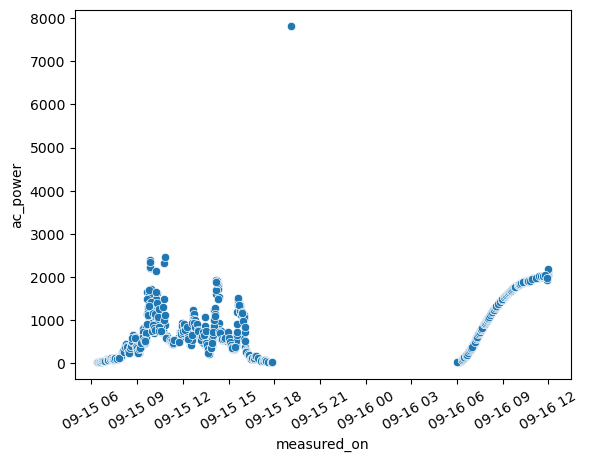

In [90]:
df_33_2011 = df_33[
    df_33['measured_on'].dt.year==2011
]
df_33_2011_pos = df_33_2011[
    (df_33_2011['value'] > 20)
    & (df_33_2011['measured_on'] >= datetime(2011, 9, 15, 1))
    & (df_33_2011['measured_on'] < datetime(2011, 9, 16, 12))
]
ax = sns.scatterplot(
    data=df_33_2011_pos,
    x = 'measured_on',
    y = 'value'
)
ax.tick_params('x', labelrotation=30)
plt.ylabel('ac_power')
plt.show()

## System 34

In [162]:
system_id = 34
relevant_rows_metrics = metrics_df[metrics_df['system_id'] == system_id]
metrics_search_for_two_fragments_df(relevant_rows_metrics, 'pow', 'ac', 'and')

,system_id,metric_id,sensor_name,common_name,raw_units,units,calc_scale,calc_offset,calc_details,aggregation_type,source_type,source_id,comments,standard_name
1320,34,2695,ac_power_hW,AC power,W,W,100.000,0.0,,avg,NaN,NaN,,ac_power_hw__2695
1323,34,2693,power_factor_1000,AC other,-,-,0.001,0.0,,avg,NaN,NaN,,power_factor_1000__2693


In [164]:
path_34 = Path(f'../../../../data_ds_project/systems/parquet/34/')
pq_34  = pq.ParquetDataset(
    path_34, filters=[
            ('metric_id', 'in', [2695])
    ]
)
df_34 = pq_34.read().to_pandas()
df_34 = df_34.drop_duplicates()
df_34.tail()

,measured_on,utc_measured_on,metric_id,value
340007,2020-07-26 11:30:00,2020-07-26 18:30:00,2695,89500.0
340008,2020-07-26 12:30:00,2020-07-26 19:30:00,2695,89200.0
340009,2020-07-26 13:30:00,2020-07-26 20:30:00,2695,103900.0
340010,2020-07-26 14:30:00,2020-07-26 21:30:00,2695,96200.0
340011,2020-07-26 15:30:00,2020-07-26 22:30:00,2695,35200.0


In [166]:
df_34_trimmed = df_34[df_34['value'] > 20]

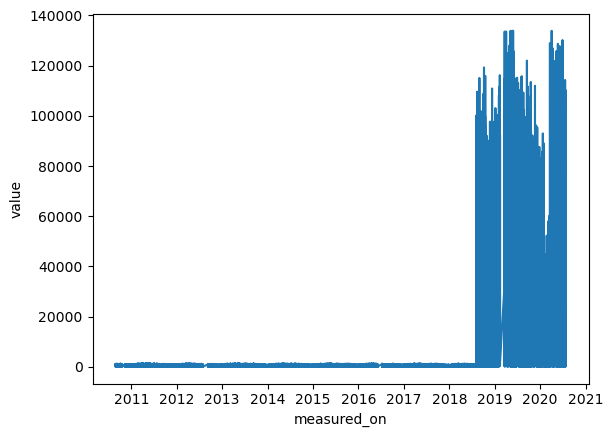

In [167]:
sns.lineplot(
    data = df_34_trimmed,
    x = 'measured_on',
    y = 'value'
)
plt.show()

### System 36

In [142]:
system_id = 36
relevant_rows_metrics = metrics_df[metrics_df['system_id'] == system_id]
metrics_search_for_two_fragments_df(relevant_rows_metrics, 'pow', 'ac', 'and')

,system_id,metric_id,sensor_name,common_name,raw_units,units,calc_scale,calc_offset,calc_details,aggregation_type,source_type,source_id,comments,standard_name
1350,36,629,ac_power,AC power,W,W,1.0,0.0,,avg,NaN,NaN,,ac_power__629


### System 50

In [91]:
system_id = 50
relevant_rows_metrics = metrics_df[metrics_df['system_id'] == system_id]
metrics_search_for_two_fragments_df(relevant_rows_metrics, 'pow', 'ac', 'and')

,system_id,metric_id,sensor_name,common_name,raw_units,units,calc_scale,calc_offset,calc_details,aggregation_type,source_type,source_id,comments,standard_name
1727,50,752,ac_power,AC power,W,W,1.0,0.0,,avg,NaN,NaN,,ac_power__752
1730,50,767,ac_power_1,AC power,W,W,1.0,0.0,,avg,NaN,NaN,,ac_power_1__767
1731,50,768,ac_power_2,AC power,W,W,1.0,0.0,,avg,NaN,NaN,,ac_power_2__768


In [93]:
path_50 = Path(f'../../../../data_ds_project/systems/parquet/50/')
pq_50 = pq.ParquetDataset(
    path_50, filters=[
            ('metric_id', 'in', [752])
    ]
)
df_50 = pq_50.read().to_pandas()
df_50 = df_50.drop_duplicates()
df_50.tail()

,measured_on,utc_measured_on,metric_id,value
5876241,2023-02-28 23:58:00,2023-03-01 06:58:00,752,-2.3939
5876242,2023-02-28 23:59:00,2023-03-01 06:59:00,752,-2.6198
5876243,2023-02-28 23:54:00,2023-03-01 06:54:00,752,-2.4617
5876244,2023-02-28 23:55:00,2023-03-01 06:55:00,752,-2.3714
5876245,2023-02-28 23:56:00,2023-03-01 06:56:00,752,-2.4616


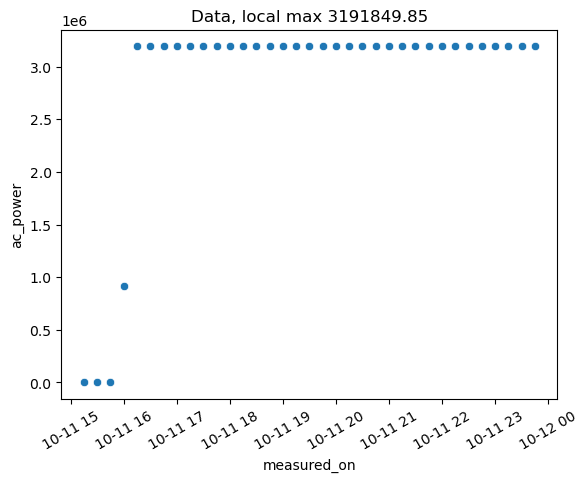

In [113]:
df_50_2004 = df_50[df_50['measured_on'].dt.year==2004]
df_50_2004_pos = df_50_2004[df_50_2004['value'] > 20]
df_50_2004_local_pos = df_50_2004_pos[
    (df_50_2004_pos['measured_on'] > datetime(2004, 10, 11, 15))
    & (df_50_2004_pos['measured_on'] < datetime(2004, 10, 12, 4))
]
local_max = df_50_2004_local_pos['value'].max()
ax = sns.scatterplot(
    data = df_50_2004_local_pos,
    x = 'measured_on',
    y = 'value'
)
ax.set(ylabel='ac_power')
ax.tick_params('x', labelrotation=30)
plt.title(f'Data, local max {local_max:.2f}')
plt.show()

### System 1200

In [119]:
system_id = 1200
relevant_rows_metrics = metrics_df[metrics_df['system_id'] == system_id]
metrics_search_for_two_fragments_df(relevant_rows_metrics, 'pow', 'ac', 'and')

,system_id,metric_id,sensor_name,common_name,raw_units,units,calc_scale,calc_offset,calc_details,aggregation_type,source_type,source_id,comments,standard_name
51,1200,2751,ac_power,AC power,W,W,1.0,0.0,ac_power_metered_kW,avg,NaN,NaN,,ac_power__2751
53,1200,2757,inv1_ac_power,AC power,W,W,1.0,0.0,,avg,NaN,NaN,,inv1_ac_power__2757
55,1200,2762,inv2_ac_power,AC power,W,W,1.0,0.0,,avg,NaN,NaN,,inv2_ac_power__2762
57,1200,2767,inv3_ac_power,AC power,W,W,1.0,0.0,,avg,NaN,NaN,,inv3_ac_power__2767
59,1200,2772,inv4_ac_power,AC power,W,W,1.0,0.0,,avg,NaN,NaN,,inv4_ac_power__2772
61,1200,2777,inv5_ac_power,AC power,W,W,1.0,0.0,,avg,NaN,NaN,,inv5_ac_power__2777
63,1200,2782,inv6_ac_power,AC power,W,W,1.0,0.0,,avg,NaN,NaN,,inv6_ac_power__2782
71,1200,4197,ac_power_metered_kW,AC power,kW,W,1000.0,0.0,,avg,NaN,NaN,,ac_power_metered_kw__4197
88,1200,4198,power_factor,AC other,-,-,1.0,0.0,,NaN,NaN,NaN,,power_factor__4198


In [120]:
path_1200 = Path(f'../../../../data_ds_project/systems/parquet/1200/')
pq_1200 = pq.ParquetDataset(
    path_1200, filters=[
            ('metric_id', 'in', [2751, 4197, 2757, 2762, 2767, 2772, 2777, 2782])
    ]
)
df_1200 = pq_1200.read().to_pandas()
df_1200 = df_1200.drop_duplicates()
df_1200.tail()

,measured_on,utc_measured_on,metric_id,value
2046368,2020-07-26 15:35:00,2020-07-26 19:35:00,4197,9620.0
2046369,2020-07-26 15:55:00,2020-07-26 19:55:00,4197,35080.0
2046370,2020-07-26 16:15:00,2020-07-26 20:15:00,4197,31880.0
2046371,2020-07-26 16:35:00,2020-07-26 20:35:00,4197,24300.0
2046372,2020-07-26 16:55:00,2020-07-26 20:55:00,4197,27060.0


In [ ]:
df_1200[['measured_on', 'metric_id']].value_counts()

Test for spread

In [ ]:
df_1200[df_1200['measured_on'] == '2018-08-04 15:10:00'].sort_values('metric_id')

A Large spread for once.  Is this widespread?

In [121]:
df_1200.loc[:, 'val_min'] = df_1200.groupby(['measured_on', 'metric_id'])['value'].transform('min')
df_1200.loc[:, 'val_max'] = df_1200.groupby(['measured_on', 'metric_id'])['value'].transform('max')
df_1200.loc[:, 'val_spread'] = df_1200['val_max'] - df_1200['val_min']
df_1200[df_1200['val_spread'] > 0.5]

,measured_on,utc_measured_on,metric_id,value,val_min,val_max,val_spread
1838259,2018-08-04 15:10:00,NaT,4197,32.78,32.78,16360.0,16327.22
1838444,2018-08-04 15:10:00,2018-08-04 19:10:00,4197,16360.00,32.78,16360.0,16327.22


OK, so it's just the one time that has a weird spread.  No other data points at that time to compare to.  What about before and after?

In [ ]:
df_1200[df_1200['measured_on'] == '2018-08-04 15:15:00'].sort_values('metric_id')

In [ ]:
df_1200[df_1200['measured_on'] == '2018-08-04 15:00:00'].sort_values('metric_id')

'So small before, huge after, and all at ~3:10 pm local time? Very strange.  I may as well just mean-it, nothing to do.

In [ ]:
df_1200[df_1200['measured_on'] == '2018-11-04 01:10:00'].sort_values('metric_id')

This is more normal.

In [122]:
df_1200 = df_1200.drop(columns='utc_measured_on')
df_1200.loc[:, 'mean_value'] = df_1200.groupby(['measured_on', 'metric_id'])['value'].transform('mean')
df_1200 = df_1200.drop(columns='value')
df_1200 = df_1200.rename(columns={'mean_value': 'value'})
df_1200 = df_1200.drop_duplicates()

In [123]:
wide_1200 = df_1200.pivot(
    index='measured_on',
    columns='metric_id',
    values='value'
)
wide_1200.columns.name = ''
wide_1200 = wide_1200.reset_index()
rename_cols = dict()
for ind in relevant_rows_metrics.index:
    rename_cols[relevant_rows_metrics.loc[ind, 'metric_id']] = relevant_rows_metrics.loc[ind, 'sensor_name']
wide_1200 = wide_1200.rename(columns=rename_cols)
wide_1200.head()

,measured_on,ac_power,inv1_ac_power,inv2_ac_power,inv3_ac_power,inv4_ac_power,inv5_ac_power,inv6_ac_power,ac_power_metered_kW
0,2010-10-03 12:15:12,NaN,1177.1463,1310.0513,1233.0250,954.2308,1093.0000,1284.8049,NaN
1,2010-10-03 12:30:12,NaN,1610.9778,1757.8000,1657.4889,1359.4222,1497.8000,1737.5556,NaN
2,2010-10-03 12:45:12,NaN,1413.0000,1545.3409,1471.0909,1205.7045,1337.0455,1516.8636,NaN
3,2010-10-03 13:00:13,NaN,1566.1731,1690.7170,1600.3585,1357.8868,1464.4717,1673.0962,NaN
4,2010-10-03 13:15:13,NaN,2810.0833,2973.9322,2854.9492,2485.1667,2682.3390,2951.1000,NaN


In [124]:
wide_1200.loc[:, 'inv_ac_total'] = wide_1200['inv1_ac_power'] + wide_1200['inv2_ac_power'] + wide_1200['inv3_ac_power']\
    + wide_1200['inv4_ac_power'] + wide_1200['inv5_ac_power'] + wide_1200['inv6_ac_power']

In [ ]:
wide_1200.head()

In [ ]:
wide_1200.loc[:, 'measured_on'] = pd.to_datetime(wide_1200.measured_on, format='%Y-%m-%d %H:%M:%S').astype('datetime64[s]')

In [ ]:
wide_1200_ac_power = wide_1200.dropna(axis=0, subset=['ac_power_metered_kW'])

In [ ]:
wide_1200_ac_power.head()

In [ ]:
wide_1200_inv_power = wide_1200.dropna(axis=0, subset=['inv_ac_total'])

In [ ]:
wide_1200_inv_power.tail(10)

In [125]:
wide_1200.describe()

,measured_on,ac_power,inv1_ac_power,inv2_ac_power,inv3_ac_power,inv4_ac_power,inv5_ac_power,inv6_ac_power,ac_power_metered_kW,inv_ac_total
count,942978,642632.000000,92226.000000,92300.000000,92199.000000,91927.000000,92150.000000,92264.000000,850651.000000,91899.000000
mean,2016-06-05 01:20:22.843965440,7032.005093,2380.696839,2500.083061,2438.065667,2310.394494,2388.754169,2459.982273,1713.426514,14519.694913
min,2010-10-03 12:15:12,-140.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-60.000000,0.000000
25%,2014-09-24 15:39:45,20.000000,359.205550,421.460550,382.171900,316.111450,343.266700,394.891675,0.020000,2304.448360
50%,2016-02-01 07:07:30,20.000000,1529.266683,1791.033350,1641.733300,1307.533300,1427.622800,1696.767850,3.440000,9655.099900
75%,2018-04-29 21:38:45,8660.000000,4358.163150,4484.815600,4451.314150,4302.372250,4407.017825,4453.573475,20.000000,26242.099650
max,2020-07-26 17:00:00,48120.000000,8110.722200,8110.789500,8110.388900,8112.352900,8116.055600,8110.833300,48160.000000,48662.719300
std,NaN,11968.103712,2262.983145,2252.830335,2268.381094,2303.891003,2336.110476,2259.899574,6581.948661,13597.024092


In [ ]:
wide_1200_all = wide_1200.dropna(axis=0)

In [ ]:
wide_1200_all.shape

<Axes: xlabel='ac_power', ylabel='ac_power_metered_kW'>

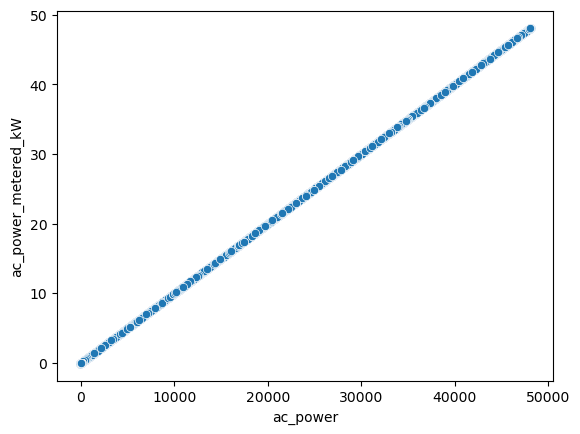

In [128]:
sns.scatterplot(
    data = wide_1200,
    x = 'ac_power',
    y = 'ac_power_metered_kW'
)

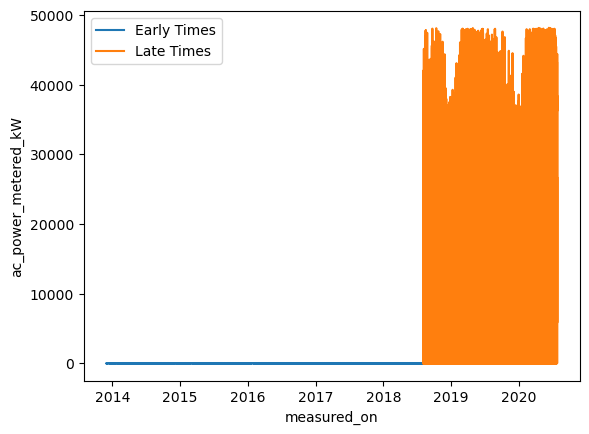

In [150]:
sns.lineplot(
    data = wide_1200[wide_1200['measured_on'] <= datetime(2018, 8, 4, 4)],
    x = 'measured_on',
    y = 'ac_power_metered_kW',
    label = 'Early Times'
)
sns.lineplot(
    data = wide_1200[wide_1200['measured_on'] >= datetime(2018, 8, 4, 5)],
    x = 'measured_on',
    y = 'ac_power_metered_kW',
    label = 'Late Times'
)
plt.legend()
plt.show()

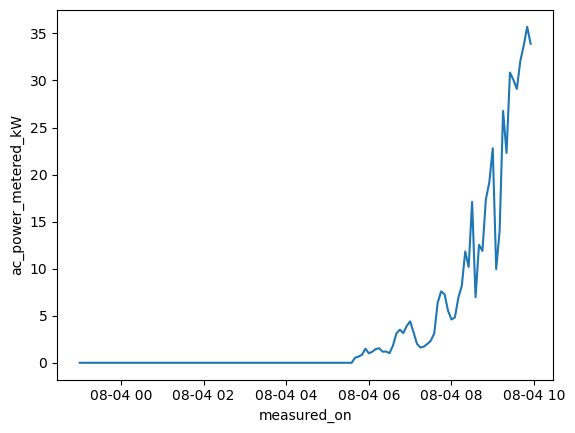

In [146]:
sns.lineplot(
    data = wide_1200[(wide_1200['measured_on'] >= datetime(2018, 8, 3, 23))
                     & (wide_1200['measured_on'] < datetime(2018, 8, 4, 10))],
    x = 'measured_on',
    y = 'ac_power_metered_kW',
)
plt.show()

In [144]:
wide_1200[~wide_1200['ac_power'].isna()]['measured_on'].max()

Timestamp('2018-08-04 05:10:00')

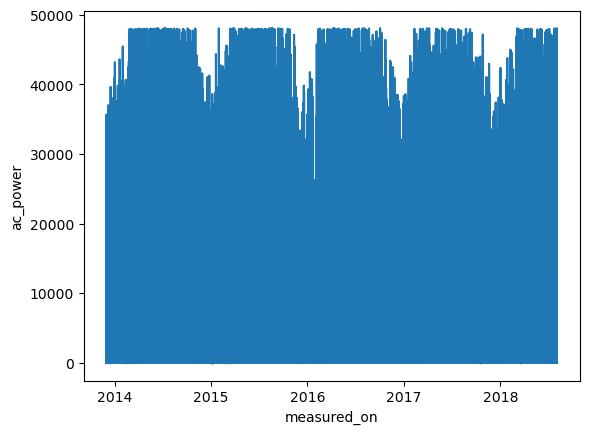

In [127]:
sns.lineplot(
    data = wide_1200,
    x = 'measured_on',
    y = 'ac_power'
)
plt.show()

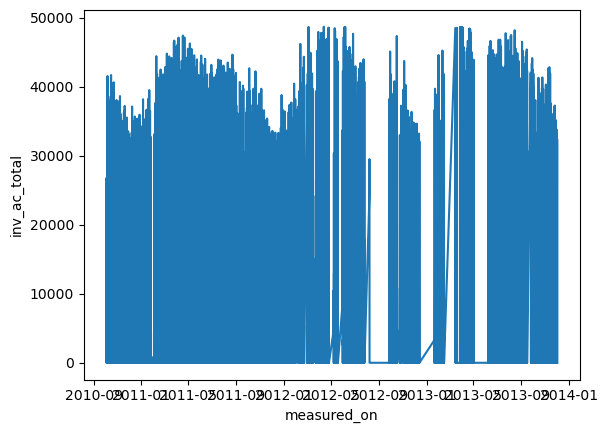

In [130]:
sns.lineplot(
    data = wide_1200,
    x = 'measured_on',
    y = 'inv_ac_total'
)
plt.show()

In [131]:
wide_1200_missing = wide_1200.isna()
wide_1200_missing[['inv_ac_total', 'ac_power', 'ac_power_metered_kW']].value_counts()

inv_ac_total  ac_power  ac_power_metered_kW
True          False     False                  642632
              True      False                  208019
False         True      True                    91899
True          True      True                      428
Name: count, dtype: int64

For System 1200, ac_power is ac_power_metered_W vs. kW!  Good to know.  (ac_power has less missingness)
Except that inv_ac_total is the true power before 2013, and ac_power scales from kW to W early Aug. 4, 2018, 5:10 am!

In [ ]:
ac_power_max = wide_1200['ac_power'].max()
wide_1200_trimmed = wide_1200[wide_1200['ac_power'] > 0.01 * ac_power_max]

In [ ]:
wide_1200_trimmed.describe()

In [ ]:
exxes = wide_1200_all['ac_power'].values
eyyes = wide_1200_all['inv_ac_total'].values
eyyes

In [ ]:
exxes

In [ ]:
sns.scatterplot(
    x = wide_1200_all['ac_power'].values,
    y = wide_1200_all['inv_ac_total'].values
)
plt.show()

Not an error!  Never recorded at the same time!

#### System 1201

In [177]:
system_id = 1201
relevant_rows_metrics = metrics_df[metrics_df['system_id'] == system_id]
metrics_search_for_two_fragments_df(relevant_rows_metrics, 'pow', 'ac', 'and')

,system_id,metric_id,sensor_name,common_name,raw_units,units,calc_scale,calc_offset,calc_details,aggregation_type,source_type,source_id,comments,standard_name
91,1201,2801,ac_power_hW,AC power,W,W,100.0,0.0,,avg,NaN,NaN,,ac_power_hw__2801
94,1201,2799,power_factor,AC other,-,-,1.0,0.0,,avg,NaN,NaN,,power_factor__2799


In [179]:
path_1201 = Path(f'../../../../data_ds_project/systems/parquet/1201/')
pq_1201 = pq.ParquetDataset(
    path_1201, filters=[
            ('metric_id', 'in', [2801])
    ]
)
df_1201 = pq_1201.read().to_pandas()
df_1201 = df_1201.drop_duplicates()
df_1201.tail()

,measured_on,utc_measured_on,metric_id,value
1349196,2020-07-26 15:30:00,2020-07-26 19:30:00,2801,77300.0
1349197,2020-07-26 15:50:00,2020-07-26 19:50:00,2801,90700.0
1349198,2020-07-26 16:10:00,2020-07-26 20:10:00,2801,93400.0
1349199,2020-07-26 16:30:00,2020-07-26 20:30:00,2801,83300.0
1349200,2020-07-26 16:50:00,2020-07-26 20:50:00,2801,60800.0


In [181]:
df_1201_trimmed = df_1201[df_1201['value'] > 20]
df_1201_trimmed['year'] = df_1201_trimmed['measured_on'].dt.year
df_1201_trimmed.groupby('year')['value'].max()

year
2011      1339.0
2012      1336.0
2013      1340.0
2014      1340.0
2015      1339.0
2016      1339.0
2017      1339.0
2018    132900.0
2019    134000.0
2020    134000.0
Name: value, dtype: float64

### System 1202

In [ ]:
system_id = 1202
relevant_rows_metrics = metrics_df[metrics_df['system_id'] == system_id]
metrics_search_for_two_fragments_df(relevant_rows_metrics, 'pow', 'ac', 'and')

In [ ]:
path_1202 = Path(f'../../../../data_ds_project/systems/parquet/1202/')
pq_1202 = pq.ParquetDataset(
    path_1202, filters=[
            ('metric_id', 'in', [2810, 2815, 2820, 2825, 2830, 2835, 2840, 2802])
    ]
)
df_1202 = pq_1202.read().to_pandas()
df_1202 = df_1202.drop_duplicates()
df_1202.tail()

In [ ]:
df_1202[['measured_on', 'metric_id']].value_counts()

In [ ]:
df_1202.loc[:, 'val_min'] = df_1202.groupby(['measured_on', 'metric_id'])['value'].transform('min')
df_1202.loc[:, 'val_max'] = df_1202.groupby(['measured_on', 'metric_id'])['value'].transform('max')
df_1202.loc[:, 'val_spread'] = df_1202['val_max'] - df_1202['val_min']
df_1202[df_1202['val_spread'] > 0.5]

Same issue!

In [ ]:
df_1202 = df_1202.drop(columns='utc_measured_on')
df_1202.loc[:, 'mean_value'] = df_1202.groupby(['measured_on', 'metric_id'])['value'].transform('mean')
df_1202 = df_1202.drop(columns='value')
df_1202 = df_1202.rename(columns={'mean_value': 'value'})
df_1202 = df_1202.drop_duplicates()

In [ ]:
wide_1202 = df_1202.pivot(
    index='measured_on',
    columns='metric_id',
    values='value'
)
wide_1202.columns.name = ''
wide_1202 = wide_1202.reset_index()
rename_cols = dict()
for ind in relevant_rows_metrics.index:
    rename_cols[relevant_rows_metrics.loc[ind, 'metric_id']] = relevant_rows_metrics.loc[ind, 'sensor_name']
wide_1202 = wide_1202.rename(columns=rename_cols)
wide_1202.head()

In [ ]:
wide_1202.count()

Same issue!

In [ ]:
df_inv1 = wide_1202.dropna(axis=0, subset=['inv1_ac_power'])
df_inv1.head(10)

In [ ]:
df_ac_pow = wide_1202.dropna(axis=0, subset=['ac_power_metered_kW'])
df_ac_pow.head(10)

In [ ]:
df_ac_all = wide_1202.dropna()
df_ac_all.shape

In [ ]:
sns.scatterplot(
    data=wide_1202,
    x = 'ac_power',
    y = 'ac_power_metered_kW'
)
plt.xlabel('Sum of inverter AC powers (W)')
plt.ylabel('Metered AC power (kW)')
plt.show()

*Very* loosely correlated, though not the same missigness as before!

### System 1208

In [ ]:
system_id = 1208
relevant_rows_metrics = metrics_df[metrics_df['system_id'] == system_id]
ac_power_metrics = metrics_search_for_two_fragments_df(relevant_rows_metrics, 'pow', 'ac', 'and')
ac_non_powerfactor_metrics = ac_power_metrics[ac_power_metrics['units'].isin(['W','kW'])]
ac_non_powerfactor_metrics

In [ ]:
path_1208 = Path(f'../../../../data_ds_project/systems/parquet/1208/')
pq_1208 = pq.ParquetDataset(
    path_1208, filters=[
            ('metric_id', 'in', [1016,1017,1018,1019,1023,1133])
    ]
)
df_1208 = pq_1208.read().to_pandas()
df_1208 = df_1208.drop_duplicates()
df_1208.tail()

In [ ]:
df_1208 = df_1208.drop(columns='utc_measured_on')
df_1208 = df_1208.drop_duplicates()
df_1208[['measured_on', 'metric_id']].value_counts()

In [ ]:
df_1208.loc[:, 'mean_value'] = df_1208.groupby(['measured_on', 'metric_id'])['value'].transform('mean')
df_1208 = df_1208.drop(columns='value')
df_1208 = df_1208.rename(columns = {'mean_value': 'value'})
df_1208 = df_1208.drop_duplicates()

In [ ]:
wide_1208 = df_1208.pivot(
    index='measured_on',
    columns='metric_id',
    values='value'
)
wide_1208.columns.name = ''
wide_1208 = wide_1208.reset_index()
rename_cols = dict()
for ind in relevant_rows_metrics.index:
    rename_cols[relevant_rows_metrics.loc[ind, 'metric_id']] = relevant_rows_metrics.loc[ind, 'sensor_name']
wide_1208 = wide_1208.rename(columns=rename_cols)
wide_1208.head()

Note: It appears, at the start, that ac_power_metered_kW is in kW, not W

In [ ]:
wide_1208.loc[:, 'year'] = wide_1208.measured_on.dt.year

In [ ]:
wide_1208[['year', 'ac_power_metered_converted_to_W', 'ac_power_metered_1_2']].sample(15)

Note: clearly ac_power_metered_1_2 is in W and ac_power_metered_kW is in kW.

In [ ]:
wide_1208.count()

In [ ]:
wide_1208_emptiness = wide_1208.isna()
wide_1208_emptiness[['ac_power_metered_kW', 'ac_power_metered_1_2']].value_counts()

#### ac_power_metered_kW has less missingness, but it's not uniform.
Let's also check size.

In [ ]:
for col_name in ['ac_power_metered_1_2', 'ac_power_metered_kW']:
    local_max = wide_1208[col_name].max()
    wide_1208_big = wide_1208[wide_1208[col_name] >= 0.01 * local_max]
    print(f'{col_name} has {wide_1208_big.shape[0]} big-enough terms (max {local_max})')

In [ ]:
wide_1208.loc[:, 'ac_power_metered_converted_to_W'] = wide_1208.loc[:, 'ac_power_metered_kW'] * 1000

In [ ]:
systems_cleaned[systems_cleaned['system_id']==1208]

In [ ]:
wide_1208.describe()

ac_power_metered_kW has implausibly high spikes! (500 mW vs. 500 kW)

In [ ]:
wide_1208['measured_on'].dtype

In [ ]:
wide_1208_trimmed = wide_1208[(wide_1208['ac_power_metered_kW'] > 0.02)
                              & (wide_1208['ac_power_metered_kW'] < 100)
                              & (wide_1208['ac_power_metered_1_2'] > 20)
                              & (wide_1208['ac_power_metered_1_2'] < 1e5)]

In [ ]:
sns.scatterplot(
    data = wide_1208_trimmed,
    x = 'ac_power_metered_converted_to_W',
    y = 'ac_power_metered_1_2',
    hue='year'
)
plt.show()

OK, after the conversion, far more sensible!  But ac_power_metered_1_2 is slightly better.

#### System 1294 -- scale check

In [ ]:
no_verifier_systems.head()

In [ ]:
cdp_systems = systems_cleaned[systems_cleaned['system_public_name'].str.contains('cdp', case=False)]
cdp_ids = set(cdp_systems.system_id)

In [ ]:
bad_systems_with_data = set(no_verifier_systems.system_id).intersection(metrics_id_set)

In [ ]:
len(bad_systems_with_data)

In [ ]:
for system_id in cdp_ids:
    relevant_rows_metrics = metrics_df[metrics_df['system_id']==system_id]
    pow_metrics = metrics_search_for_fragment_df(relevant_rows_metrics, 'pow')
    if pow_metrics.shape[0] > 0:
        print(f'Surprise for System {system_id}')

In [ ]:
for system_id in bad_systems_with_data:
    relevant_rows_metrics = metrics_df[metrics_df['system_id']==system_id]
    pow_metrics = metrics_search_for_fragment_df(relevant_rows_metrics, 'pow')
    if pow_metrics.shape[0] > 0:
        print(f'Surprise for System {system_id}')
        print(set(pow_metrics['sensor_name'].unique()))

All the hard-to-verify systems with power data have the *same* name for their power.

In [ ]:
for system_id in bad_systems_with_data:
    relevant_rows_metrics = metrics_df[metrics_df['system_id']==system_id]
    pow_metrics = metrics_search_for_fragment_df(relevant_rows_metrics, 'pow')
    if pow_metrics.shape[0] > 0:
        va_metrics = metrics_search_for_fragment_df(relevant_rows_metrics, 'va')
        if va_metrics.shape[0] == 0:
            print(f'Surprise for system {system_id}')

So those systems with RTW have VA data!

In [ ]:
system_id = 1296
relevant_rows_metrics = metrics_df[metrics_df['system_id']==system_id]
relevant_rows_metrics

In [ ]:
len(bad_systems_with_data)

In [ ]:
cdp_bad_systems = cdp_ids.intersection(bad_systems_with_data)

In [ ]:
non_cdp_bad_systems = bad_systems_with_data.difference(cdp_ids)

In [ ]:
non_cdp_bad_systems

In [ ]:
len(cdp_bad_systems)

In [ ]:
bad_systems_with_data

In [ ]:
system_id = 1294
relevant_rows_metrics = metrics_df[metrics_df['system_id'] == system_id]
relevant_rows_metrics


### System 1283

In [ ]:
system_id = 1283
relevant_rows_metrics = metrics_df[metrics_df['system_id'] == system_id]
metrics_search_for_two_fragments_df(relevant_rows_metrics, 'pow', 'ac', 'and')

In [ ]:
relevant_rows_metrics

In [ ]:
path_1283 = Path(f'../../../../data_ds_project/systems/parquet/1283/')
pq_1283 = pq.ParquetDataset(
    path_1283, filters=[
            ('metric_id', 'in', [1040, 1041, 1042, 1043, 1047, 1137, 1045, 1134, 1135, 1136])
    ]
)
df_1283 = pq_1283.read().to_pandas()
df_1283 = df_1283.drop_duplicates()
df_1283.tail()

In [ ]:
df_1283[['measured_on', 'metric_id']].value_counts()

In [ ]:
df_1283 = df_1283.drop(columns='utc_measured_on')
df_1283 = df_1283.drop_duplicates()

In [ ]:
df_1283[['measured_on', 'metric_id']].value_counts()

In [ ]:
df_1283[df_1283['measured_on'] == '2020-07-16 11:51:30']

In [ ]:
df_1283.loc[:, 'mean_value'] = df_1283.groupby(['measured_on', 'metric_id']).transform('mean')
df_1283 = df_1283.drop(columns='value')
df_1283 = df_1283.rename(columns={'mean_value': 'value'})
df_1283 = df_1283.drop_duplicates()

In [ ]:
wide_1283 = df_1283.pivot(
    index='measured_on',
    columns='metric_id',
    values='value'
)
wide_1283.columns.name = ''
wide_1283 = wide_1283.reset_index()
rename_cols = dict()
for ind in relevant_rows_metrics.index:
    rename_cols[relevant_rows_metrics.loc[ind, 'metric_id']] = relevant_rows_metrics.loc[ind, 'sensor_name']
wide_1283 = wide_1283.rename(columns=rename_cols)
wide_1283.head()

In [ ]:
wide_1283.loc[:, 'ac_inv_power_sum'] = wide_1283['inv1_ac_power_kW'] + wide_1283['inv2_ac_power_kW']

In [ ]:
wide_1283.describe()

In [ ]:
wide_1283['dc_power_trimmed'] = wide_1283['dc_power'].clip(upper = 3e5) 

In [ ]:
wide_1283['dc_power'].value_counts()

In [ ]:
wide_1283['dc_power_trimmed'].value_counts()

In [ ]:
wide_1283_missing = wide_1283.isna()
wide_1283_missing[['ac_power', 'ac_power_metered_kW']].value_counts()

In [ ]:
for col_name in ['ac_power', 'ac_power_metered_kW']:
    local_max = wide_1283[col_name].max()
    wide_1283_big = wide_1283[wide_1283[col_name] >= 0.01 * local_max]
    print(f'{col_name} has {wide_1283_big.shape[0]} big-enough terms (max {local_max})')

So `ac_power_metered_kW` has less missingness,
but `ac_power`has more large-enough terms.

Given the diagrams below, go with `ac_power`

In [ ]:
wide_1283_ac_power_max = wide_1283['ac_power'].max()
wide_1283_ac_power_metered_max = wide_1283['ac_power_metered_kW'].max()
wide_1283_ac_power_inv_max = wide_1283['ac_inv_power_sum'].max()

In [ ]:
wide_1283_ac_power_max

In [ ]:
wide_1283_trimmed = wide_1283[(wide_1283['ac_inv_power_sum'] > 0.01 * wide_1283_ac_power_inv_max)]

In [ ]:
wide_1283.shape

In [ ]:
wide_1283_trimmed.shape

In [ ]:
wide_1283_trimmed.count()

In [ ]:
sns.lineplot(
    data=wide_1283_trimmed,
    x='measured_on',
    y='ac_power'
)
plt.show()

In [ ]:
sns.pairplot(
    data = wide_1283_trimmed,
    vars = ['dc_power_trimmed', 'ac_inv_power_sum', 'ac_power', 'ac_power_metered_kW'],
    corner=True
)
plt.show()

In [ ]:
sns.scatterplot(
    data = wide_1283_trimmed,
    x = 'double_dc_power_trimmed',
    y = 'ac_inv_power_sum'
)

OK, so a times-2 factor to dc_power normalizes things.

In [ ]:
sns.scatterplot(
    data = wide_1283_trimmed,
    x = 'ac_power',
    y = 'inv_power_sum'
)

So all 3 of the terms are very well-behaved, but nothing is obviously right.
$P = I \cdot V$ as tiebreaker?
Well, no.  That only has DC data, and that gives the DC power that is 1/2 of the AC power, roughly.

### System 1332

In [ ]:
system_id = 1332
relevant_rows_metrics = metrics_df[metrics_df['system_id'] == system_id]
metrics_search_for_two_fragments_df(relevant_rows_metrics, 'pow', 'ac', 'and')

In [ ]:
path_1332 = Path(f'../../../../data_ds_project/systems/parquet/1332/')
pq_1332 = pq.ParquetDataset(
    path_1332, filters=[
            ('metric_id', 'in', [2654, 2638])
    ]
)
df_1332 = pq_1332.read().to_pandas()
df_1332 = df_1332.drop_duplicates()
df_1332.tail()

In [ ]:
df_1332[['measured_on', 'metric_id']].value_counts()

In [ ]:
df_1332.loc[:, 'measured_on'] = pd.to_datetime(df_1332.measured_on, format='%Y-%m-%d %H:%M:%S').astype('datetime64[s]')

In [ ]:
df_1332.loc[:, 'val_min'] = df_1332.groupby(['measured_on', 'metric_id'])['value'].transform('min')
df_1332.loc[:, 'val_max'] = df_1332.groupby(['measured_on', 'metric_id'])['value'].transform('max')
df_1332.loc[:, 'val_spread'] = df_1332['val_max'] - df_1332['val_min']

In [ ]:
df_1332_high_spread = df_1332.loc[df_1332['val_spread'] > 0.5]
df_1332_high_spread.loc[:, 'spread_date'] = df_1332_high_spread['measured_on'].dt.date
df_1332_high_spread['spread_date'].value_counts()

In [ ]:
df_1332_high_spread['measured_on'].max() - df_1332_high_spread['measured_on'].min()

High-spread occurrences isolated to 8.5 hours on Aug. 4, 2018 -- localized problem!  For exploration, just shift it!

In [ ]:
df_1332.loc[:, 'mean_value'] = df_1332.groupby(['measured_on', 'metric_id'])['value'].transform('mean')
df_1332 = df_1332.drop(columns='value')
df_1332 = df_1332.rename(columns={'mean_value': 'value'})
df_1332 = df_1332.drop_duplicates()

In [ ]:
df_1332[['measured_on', 'metric_id']].value_counts()

In [ ]:
wide_1332 = df_1332.pivot(
    index='measured_on',
    columns='metric_id',
    values='value'
)
wide_1332.columns.name = ''
wide_1332 = wide_1332.reset_index()
rename_cols = dict()
for ind in relevant_rows_metrics.index:
    rename_cols[relevant_rows_metrics.loc[ind, 'metric_id']] = relevant_rows_metrics.loc[ind, 'sensor_name']
wide_1332 = wide_1332.rename(columns=rename_cols)
wide_1332.head()

In [ ]:
wide_1332.count()

In [ ]:
wide_1332.dropna(axis=0, subset=['metered_ac_power']).count()

In [ ]:
wide_1332.dropna(axis=0, subset=['inv_total_ac_power']).count()

Only 9 times have missing metered_ac_power, but inv_total_ac_power shows up only about a 3rd of the time!

In [ ]:
systems_cleaned[systems_cleaned['system_id'] == 1332]

In [ ]:
wide_1332_trimmed = wide_1332[
    (wide_1332['metered_ac_power'] > 0.5)
    & (wide_1332['metered_ac_power'] < 1153*2)
    & (wide_1332['inv_total_ac_power'] > 500)
    & (wide_1332['inv_total_ac_power'] < 1153 * 2000)
]

In [ ]:
sns.scatterplot(
    data=wide_1332_trimmed,
    x = 'inv_total_ac_power',
    y = 'metered_ac_power'
)
plt.show()

Reasonably co-variant!

In [ ]:
sns.scatterplot(
    data = wide_1332_trimmed,
    x = 'measured_on',
    y = 'inv_total_ac_power',
    label = 'Inverter Power (W)'
)
sns.scatterplot(
    data = wide_1332_trimmed,
    x = 'measured_on',
    y = 'metered_ac_power',
    label='Metered AC power (kW)'
)
plt.legend()
plt.show()

### System 1416

In [ ]:
system_id = 1416
relevant_rows_metrics = metrics_df[metrics_df['system_id'] == system_id]
metrics_search_for_two_fragments_df(relevant_rows_metrics, 'pow', 'ac', 'and')

In [ ]:
relevant_rows_metrics[relevant_rows_metrics['common_name'].str.contains('pow')]

In [ ]:
path_1416= Path(f'../../../../data_ds_project/systems/parquet/1416/')
pq_1416 = pq.ParquetDataset(
    path_1416, filters=[
            ('metric_id', 'in', [4738, 4741, 4742])
    ]
)
df_1416 = pq_1416.read().to_pandas()
df_1416 = df_1416.drop_duplicates()
df_1416.tail()

In [ ]:
df_1416_wide = df_1416.pivot(
    index='measured_on',
    columns = 'metric_id',
    values='value'
)
df_1416_wide.columns.name = ''
df_1416_wide = df_1416_wide.reset_index()
df_1416_wide = df_1416_wide.rename(columns={
    4738: 'dc_power_positive',
    4741: 'dc_power_negative',
    4742: 'dc_power'
})

In [ ]:
df_1416_wide

In [ ]:
df_1416_wide['manual_sum'] = df_1416_wide['dc_power_positive'] + df_1416_wide['dc_power_negative']
df_1416_wide['manual_diff'] = df_1416_wide['dc_power_positive'] - df_1416_wide['dc_power_negative']

In [ ]:
df_1416_wide['dc_power_negative'].describe()

In [ ]:
df_1416_wide.sample(15)

#### System 1422

In [ ]:
system_id = 1422
relevant_rows_metrics = metrics_df[metrics_df['system_id'] == system_id]
all_pow_met = metrics_search_for_fragment_df(relevant_rows_metrics, 'pow')
all_pow_met

In [ ]:
path_1422= Path(f'../../../../data_ds_project/systems/parquet/1422/')
pq_1422 = pq.ParquetDataset(
    path_1422, filters=[
            ('metric_id', 'in', [4830, 4836, 5375, 5376])
    ]
)
df_1422 = pq_1422.read().to_pandas()
df_1422 = df_1422.drop_duplicates()
df_1422.tail()

In [ ]:
df_1422.head()

In [ ]:
set(df_1422['metric_id'])

In [ ]:
#last check -- find all metrics in a single year (to keep file-size down)
pq_1422_2018 = pq.ParquetDataset(
    path_1422, filters=[
            ('measured_on', '>=', datetime(2018, 1, 1)),
            ('measured_on', '<', datetime(2019, 1, 1))
    ]
)
df_1422_2018 = pq_1422_2018.read().to_pandas()
df_1422_2018 = df_1422_2018.drop_duplicates()
df_1422_2018.tail()

In [ ]:
set(df_1422_2018['metric_id'])

Check against start

In [ ]:
pq_1422_2014 = pq.ParquetDataset(
    path_1422, filters=[
            ('measured_on', '>=', datetime(2014, 1, 1)),
            ('measured_on', '<', datetime(2015, 1, 1))
    ]
)
df_1422_2014 = pq_1422_2014.read().to_pandas()
df_1422_2014 = df_1422_2014.drop_duplicates()
df_1422_2014.tail()

In [ ]:
set(df_1422_2014['metric_id'])

In [ ]:
unused_metrics = set(relevant_rows_metrics['metric_id']).difference(set(df_1422_2014.metric_id))
unused_metrics

So exactly the dc power and ac power accumulators are missing!

### System 4903 -- outliers

In [114]:
system_id = 4903
relevant_rows_metrics = metrics_df[metrics_df['system_id'] == system_id]
metrics_search_for_fragment_df(relevant_rows_metrics, 'InvPAC_kW_Avg')


,system_id,metric_id,sensor_name,common_name,raw_units,units,calc_scale,calc_offset,calc_details,aggregation_type,source_type,source_id,comments,standard_name
1606,4903,82728,InvPAC_kW_Avg,AC power,kW,kW,1.0,0.0,,avg,INVERTER,14539.0,,ac_power_inv_14539


In [115]:
path_4903 = Path(f'../../../../data_ds_project/systems/parquet/4903/')
pq_4903 = pq.ParquetDataset(
    path_4903, filters=[
            ('metric_id', 'in', [82728])
    ]
)
df_4903 = pq_4903.read().to_pandas()
df_4903 = df_4903.drop_duplicates()
df_4903.tail()

,measured_on,utc_measured_on,metric_id,value
2013573,2018-03-14 23:56:00,2018-03-15 04:56:00,82728,-0.103
2013574,2018-03-14 23:53:00,2018-03-15 04:53:00,82728,-0.103
2013575,2018-03-14 23:57:00,2018-03-15 04:57:00,82728,-0.102
2013576,2018-03-14 23:54:00,2018-03-15 04:54:00,82728,-0.102
2013577,2018-03-14 23:58:00,2018-03-15 04:58:00,82728,-0.100


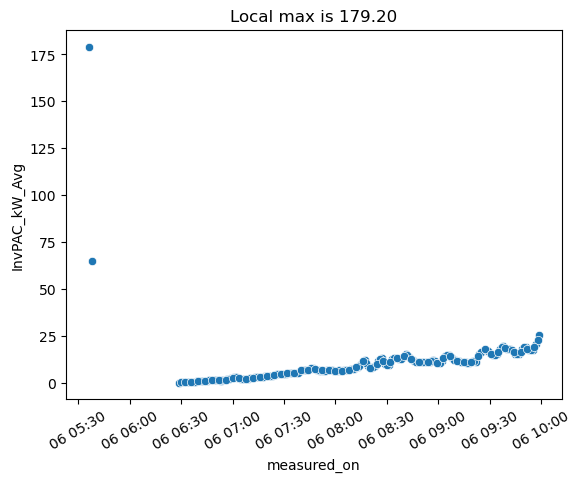

In [125]:
df_4903_2016 = df_4903[df_4903['measured_on'].dt.year==2016]
df_4903_2016_pos = df_4903[df_4903['value'] > 0.02]  # kW
df_4903_2016_local_pos = df_4903_2016_pos[
    (df_4903_2016_pos['measured_on'] >= datetime(2016, 10, 5, 20))
    & (df_4903_2016_pos['measured_on'] < datetime(2016, 10, 6, 10))
]
local_max = df_4903_2016_local_pos['value'].max()
ax = sns.scatterplot(
    data = df_4903_2016_local_pos,
    x = 'measured_on',
    y = 'value'
)
ax.set(ylabel='InvPAC_kW_Avg')
ax.tick_params('x', labelrotation=30)
plt.title(f'Local max is {local_max:.2f}')
plt.show()

In [136]:
two_years_days = 2 * 365
enough_data_systems = systems_cleaned[systems_cleaned['num_days_actual_records'] >= two_years_days]
enough_data_ids = set(enough_data_systems.system_id)
ac_pow_systems = metrics_search_for_two_fragments_df(metrics_df, 'ac', 'pow', 'and')
ac_pow_ids = set(ac_pow_systems.system_id)
enough_ac_pow_ids = enough_data_ids.intersection(ac_pow_ids)
len(enough_ac_pow_ids)

82